# CNN Comparison Report

This notebook compares several CNN variants trained on MNIST.

In [1]:
import json
from pathlib import Path
from IPython.display import Image, display

COMPARISON_DIR = Path(r"C:\Users\emil_\vscode\Assignment1\part_2\outputs\cnn_comparison_2026-04-28_154826")
RUN_NAMES = ['cnn_small', 'cnn_medium', 'cnn_dropout', 'cnn_deep_balanced', 'cnn_deep_wide']
RUN_DIRS = {'cnn_small': 'C:\\Users\\emil_\\vscode\\Assignment1\\part_2\\outputs\\cnn_comparison_2026-04-28_154826\\cnn_small', 'cnn_medium': 'C:\\Users\\emil_\\vscode\\Assignment1\\part_2\\outputs\\cnn_comparison_2026-04-28_154826\\cnn_medium', 'cnn_dropout': 'C:\\Users\\emil_\\vscode\\Assignment1\\part_2\\outputs\\cnn_comparison_2026-04-28_154826\\cnn_dropout', 'cnn_deep_balanced': 'C:\\Users\\emil_\\vscode\\Assignment1\\part_2\\outputs\\cnn_comparison_2026-04-28_154826\\cnn_deep_balanced', 'cnn_deep_wide': 'C:\\Users\\emil_\\vscode\\Assignment1\\part_2\\outputs\\cnn_comparison_2026-04-28_154826\\cnn_deep_wide'}

def load_json(path):
    return json.loads(Path(path).read_text(encoding='utf-8'))


## Summary Table

In [2]:
rows = []
for run_name in RUN_NAMES:
    run_dir = Path(RUN_DIRS[run_name])
    summary = load_json(run_dir / 'summary.json')
    config = load_json(run_dir / 'config.json')
    rows.append({
        'model': run_name,
        'best_epoch': summary['best_epoch'],
        'best_val_loss': summary['best_validation_loss'],
        'best_val_acc': summary['best_validation_accuracy'],
        'test_acc': summary['final_test_accuracy'],
        'total_time_s': summary['total_training_time_seconds'],
        'conv_channels': config.get('conv_channels'),
        'num_conv_layers': config.get('num_conv_layers', 0),
        'trainable_parameters': config.get('trainable_parameters'),
        'dropout': config.get('dropout', 0.0),
        'activation': config.get('activation'),
    })
rows

[{'model': 'cnn_small',
  'best_epoch': 4,
  'best_val_loss': 0.04752257223924001,
  'best_val_acc': 0.9871666666666666,
  'test_acc': 0.988,
  'total_time_s': 37.29275329999655,
  'conv_channels': [16, 32],
  'num_conv_layers': 2,
  'trainable_parameters': 105866,
  'dropout': 0.0,
  'activation': 'ReLU'},
 {'model': 'cnn_medium',
  'best_epoch': 4,
  'best_val_loss': 0.03860566270103057,
  'best_val_acc': 0.9886666666666667,
  'test_acc': 0.9911,
  'total_time_s': 36.361532400002034,
  'conv_channels': [32, 64],
  'num_conv_layers': 2,
  'trainable_parameters': 421642,
  'dropout': 0.0,
  'activation': 'LeakyReLU'},
 {'model': 'cnn_dropout',
  'best_epoch': 4,
  'best_val_loss': 0.03926644350526234,
  'best_val_acc': 0.9891666666666666,
  'test_acc': 0.9903,
  'total_time_s': 37.44638599999962,
  'conv_channels': [32, 64],
  'num_conv_layers': 2,
  'trainable_parameters': 421642,
  'dropout': 0.3,
  'activation': 'ReLU'},
 {'model': 'cnn_deep_balanced',
  'best_epoch': 4,
  'best_val

## Parameter-Aware Comparison

When evaluating architecture changes, models with very different parameter counts should not be treated as a clean apples-to-apples comparison. Use the table below to compare depth changes while keeping parameter counts reasonably close.

In [3]:
sorted_rows = sorted(rows, key=lambda row: row['trainable_parameters'] or 0)
sorted_rows

[{'model': 'cnn_small',
  'best_epoch': 4,
  'best_val_loss': 0.04752257223924001,
  'best_val_acc': 0.9871666666666666,
  'test_acc': 0.988,
  'total_time_s': 37.29275329999655,
  'conv_channels': [16, 32],
  'num_conv_layers': 2,
  'trainable_parameters': 105866,
  'dropout': 0.0,
  'activation': 'ReLU'},
 {'model': 'cnn_deep_balanced',
  'best_epoch': 4,
  'best_val_loss': 0.03705980129446834,
  'best_val_acc': 0.9905,
  'test_acc': 0.9914,
  'total_time_s': 38.6434416000011,
  'conv_channels': [32, 64, 64],
  'num_conv_layers': 3,
  'trainable_parameters': 356298,
  'dropout': 0.0,
  'activation': 'ReLU'},
 {'model': 'cnn_deep_wide',
  'best_epoch': 4,
  'best_val_loss': 0.03225172880540291,
  'best_val_acc': 0.9905,
  'test_acc': 0.9926,
  'total_time_s': 39.844052999997075,
  'conv_channels': [32, 64, 128],
  'num_conv_layers': 3,
  'trainable_parameters': 390410,
  'dropout': 0.0,
  'activation': 'ReLU'},
 {'model': 'cnn_medium',
  'best_epoch': 4,
  'best_val_loss': 0.038605662

## Saved Plots


## cnn_small
loss_curve.png


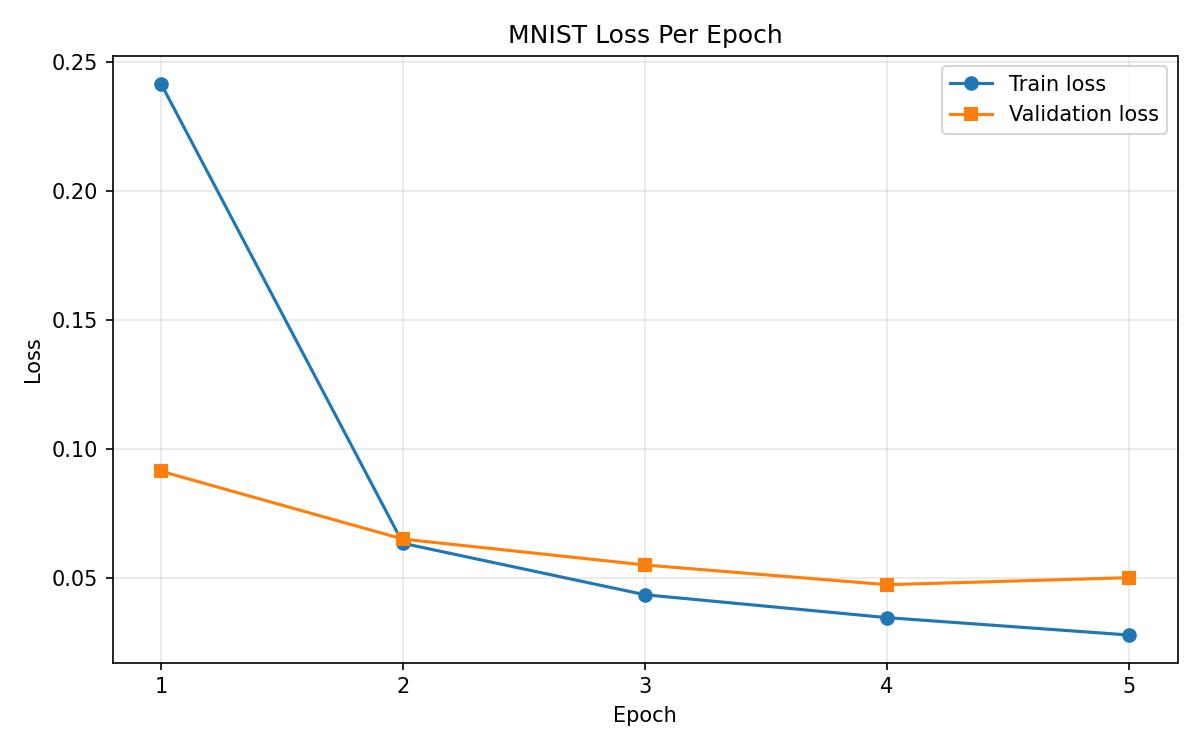

accuracy_curve.png


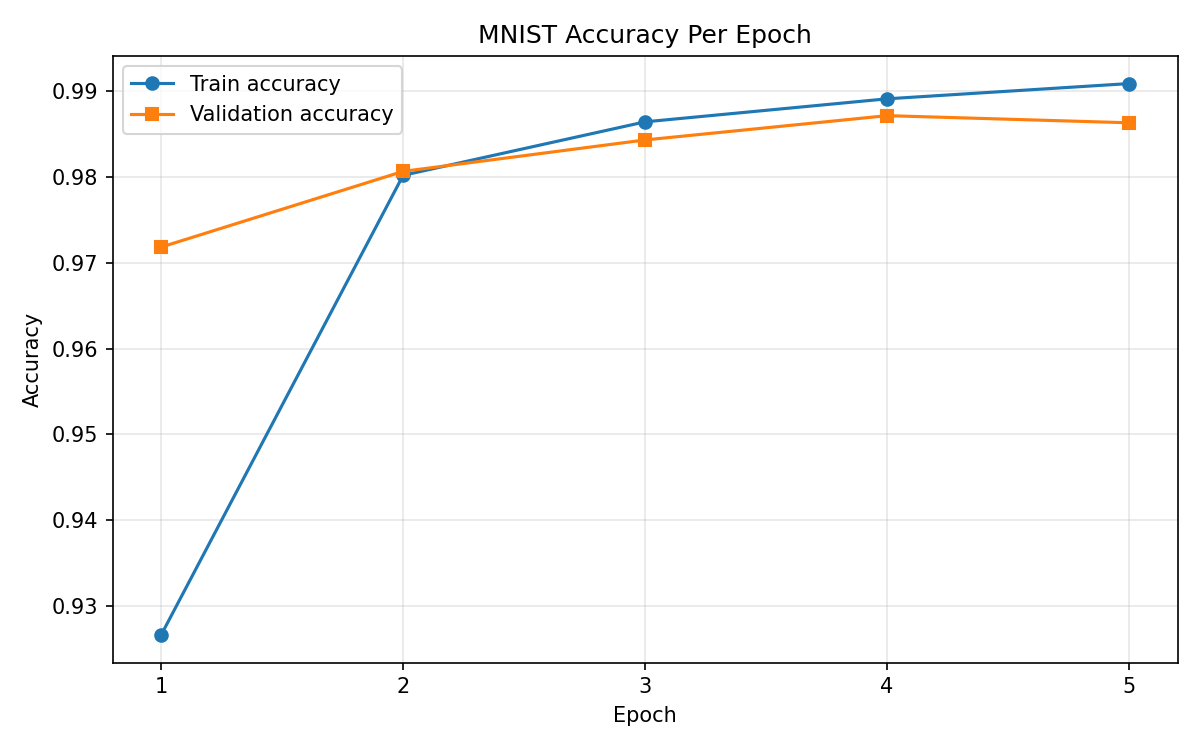

confusion_matrix.png


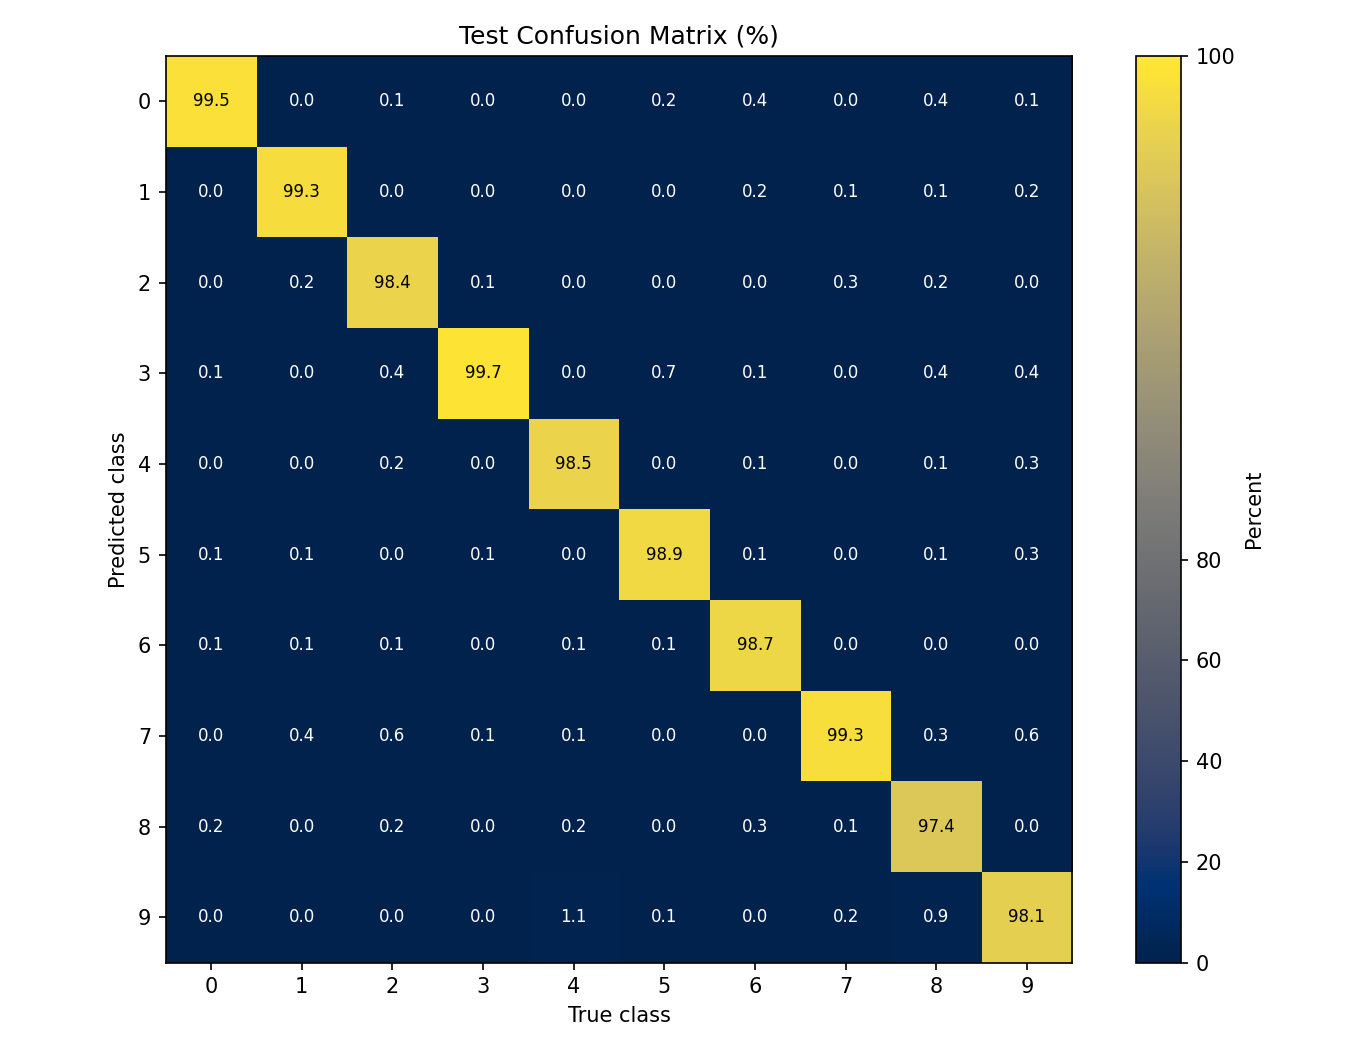


## cnn_medium
loss_curve.png


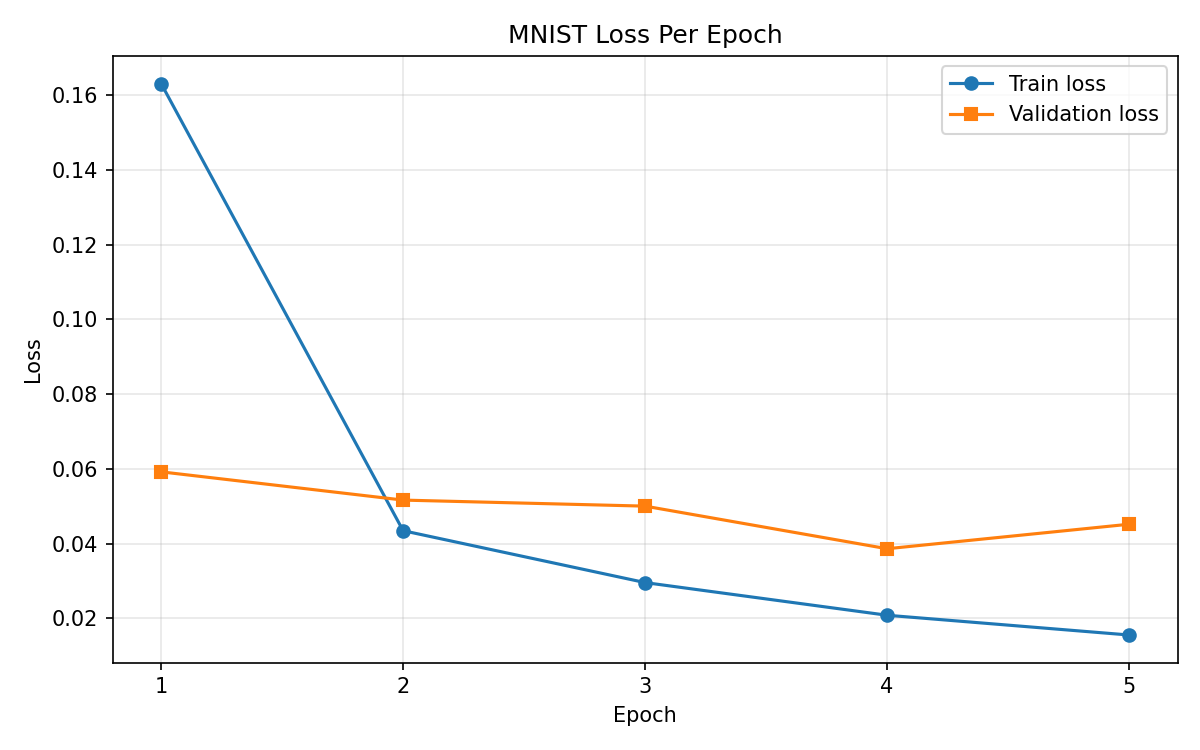

accuracy_curve.png


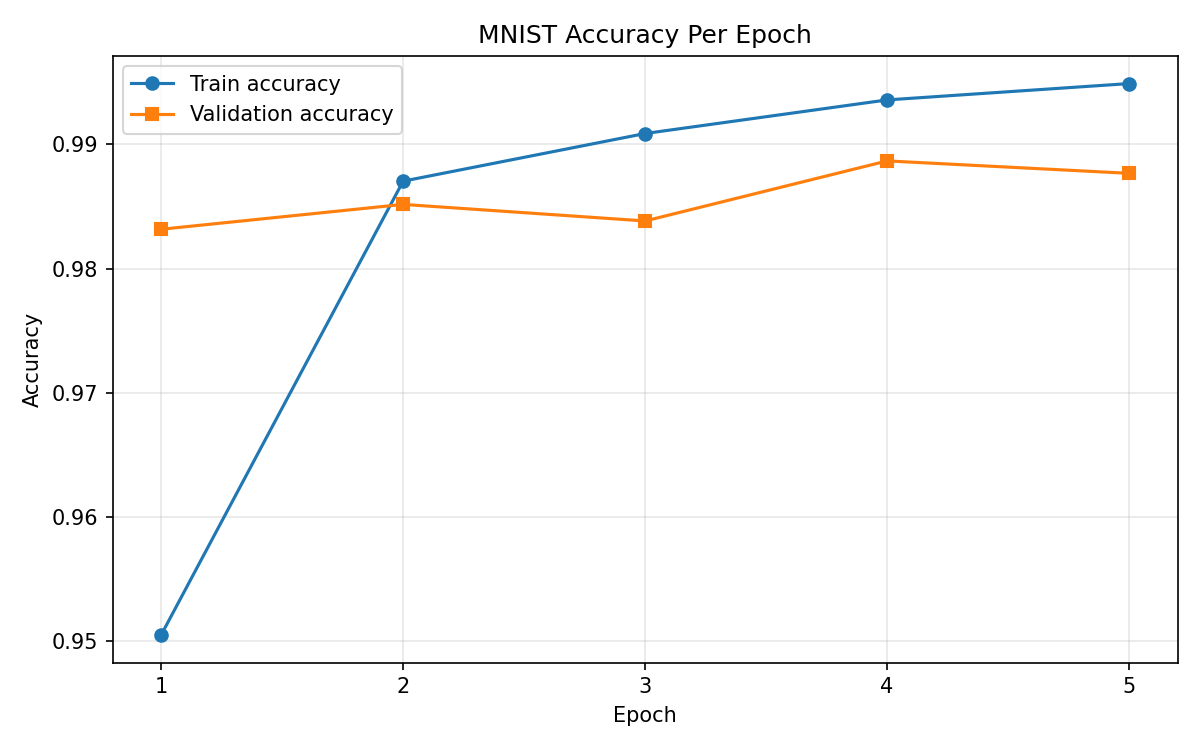

confusion_matrix.png


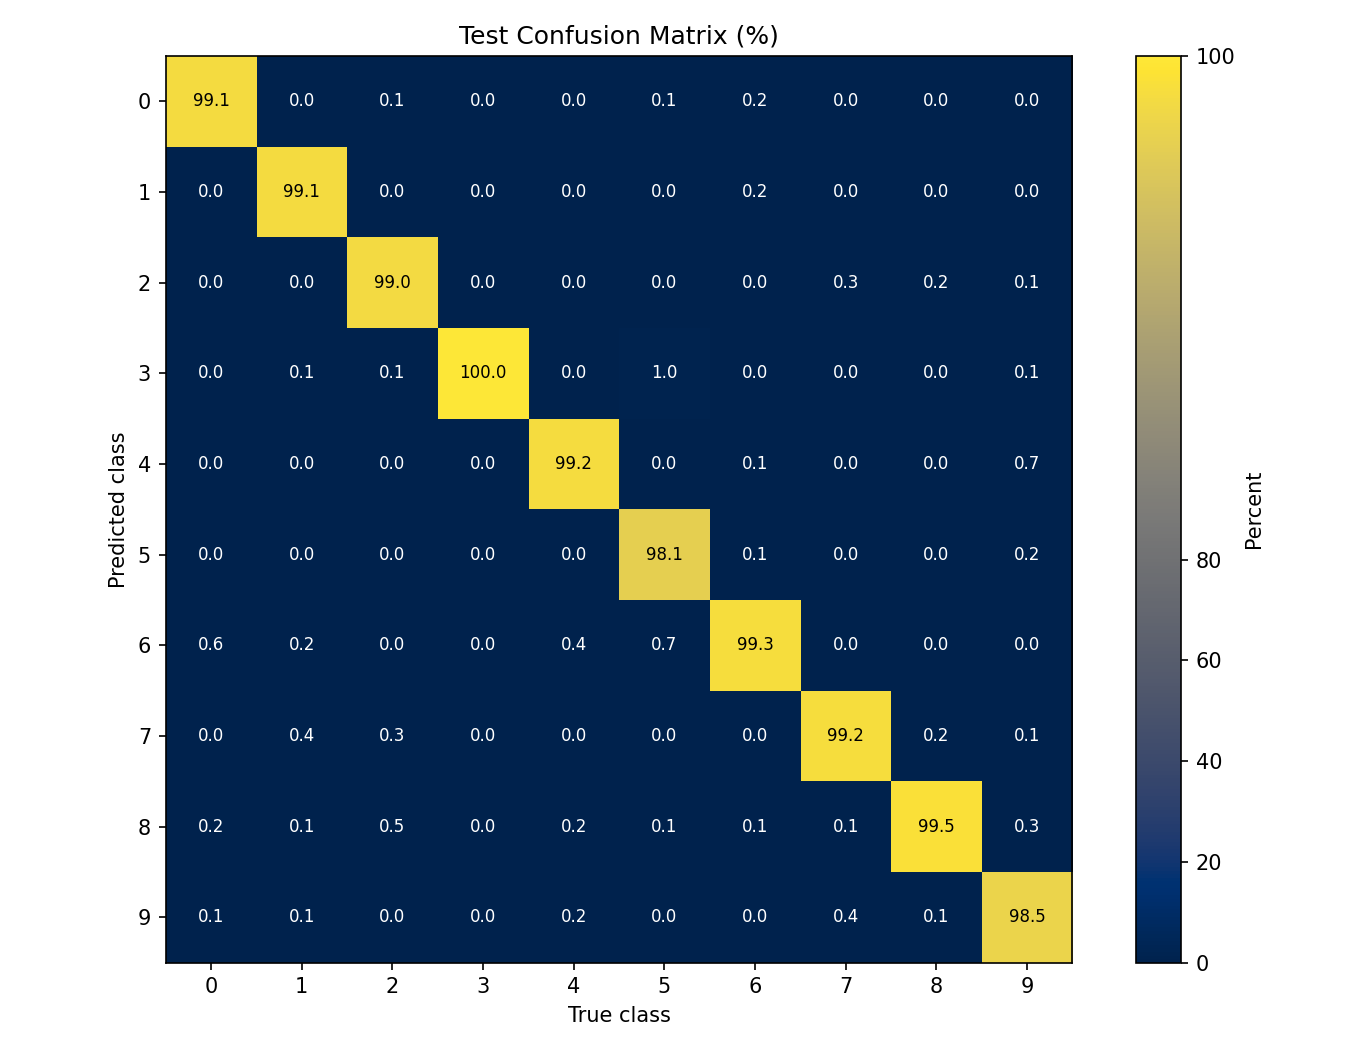


## cnn_dropout
loss_curve.png


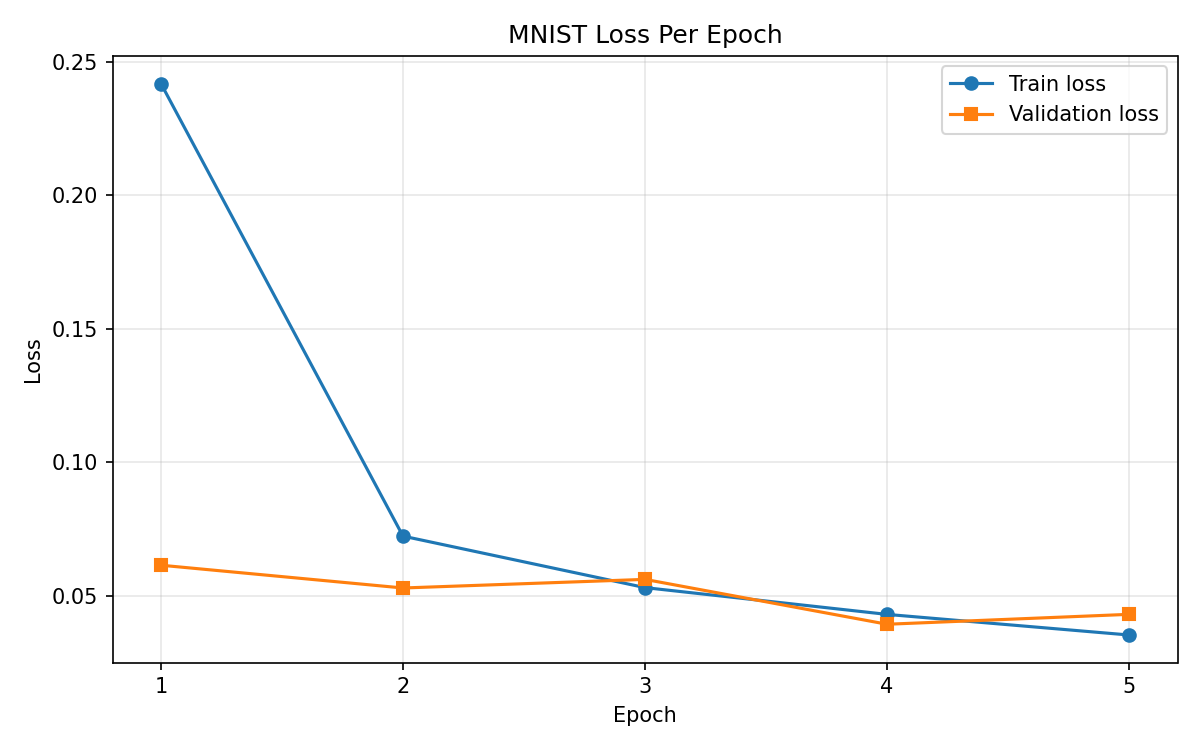

accuracy_curve.png


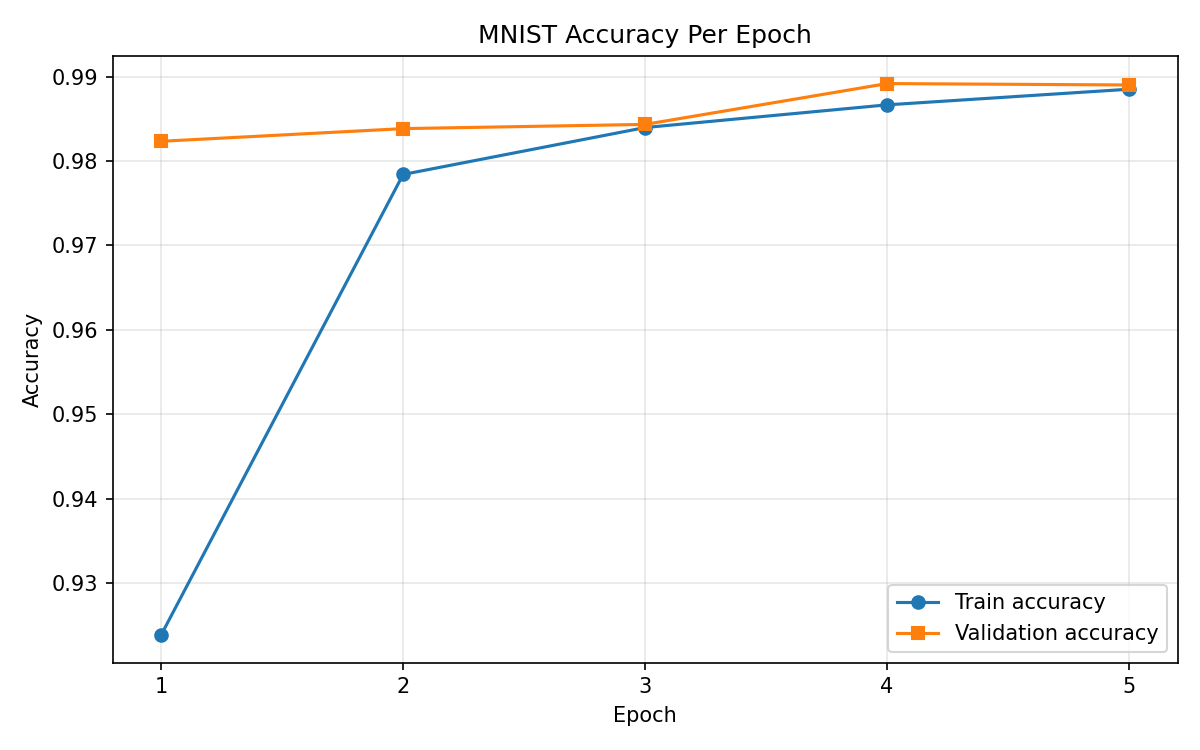

confusion_matrix.png


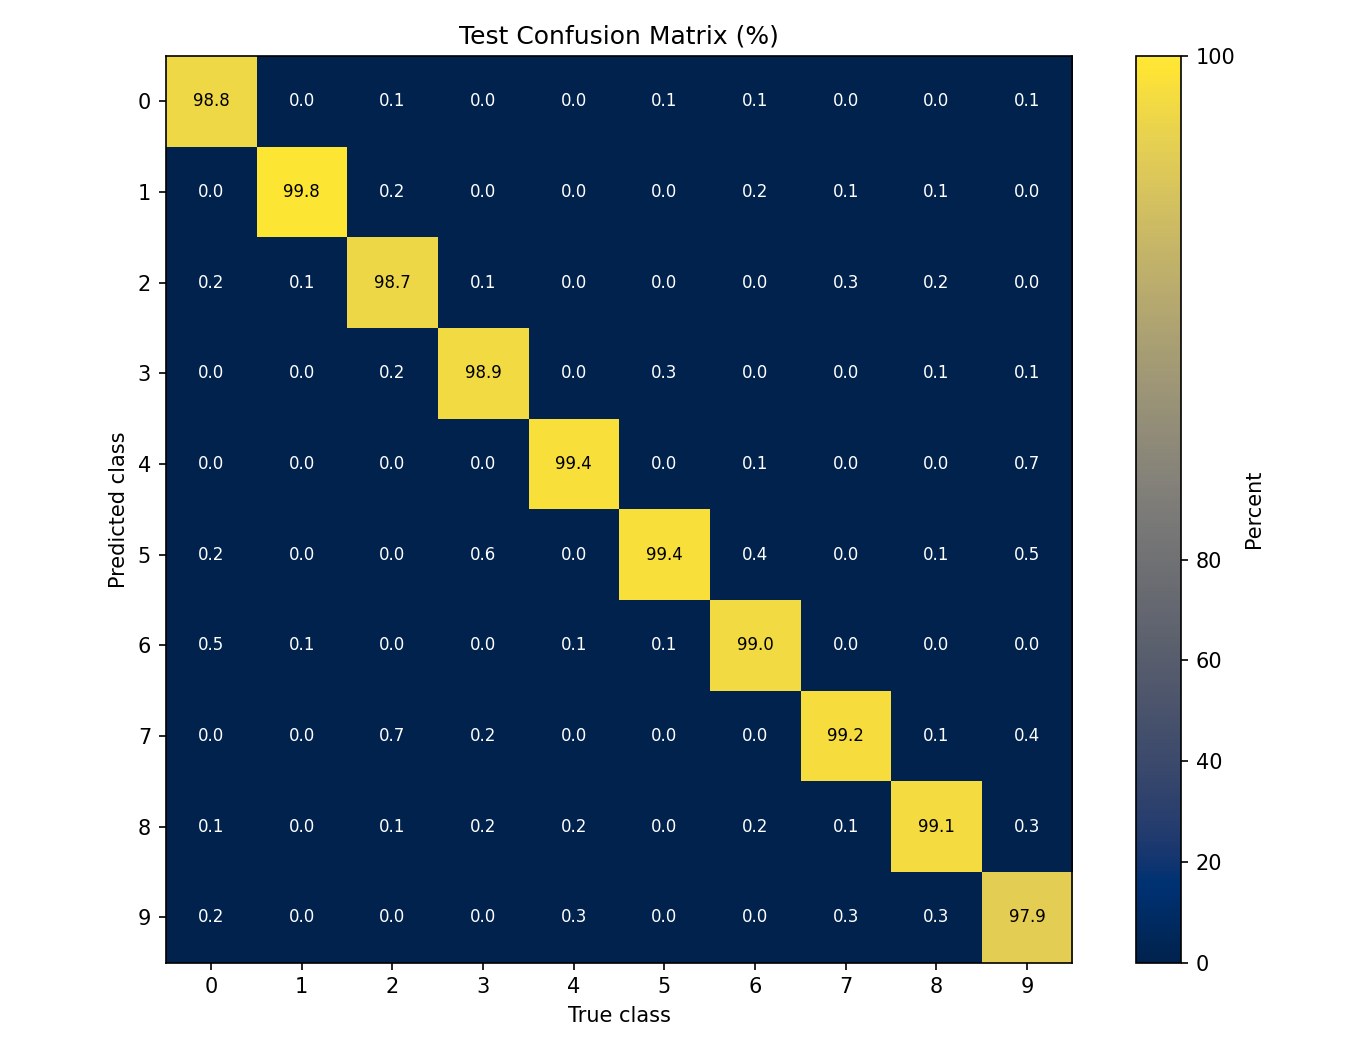


## cnn_deep_balanced
loss_curve.png


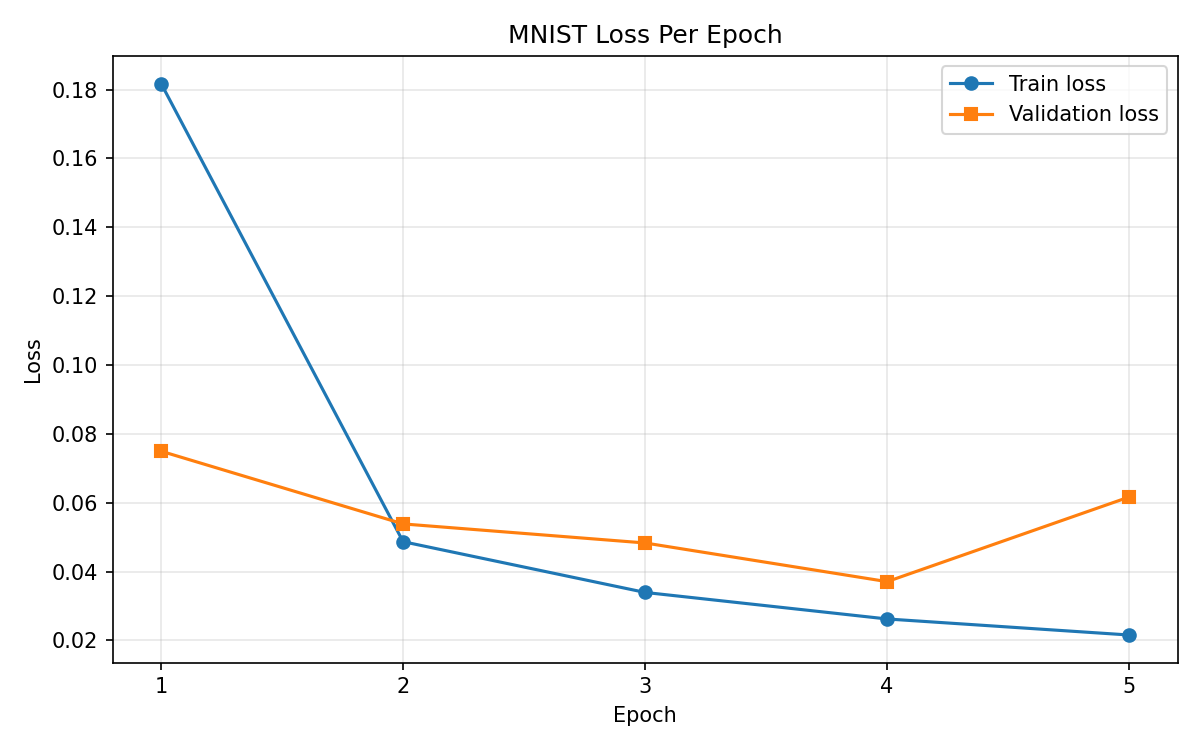

accuracy_curve.png


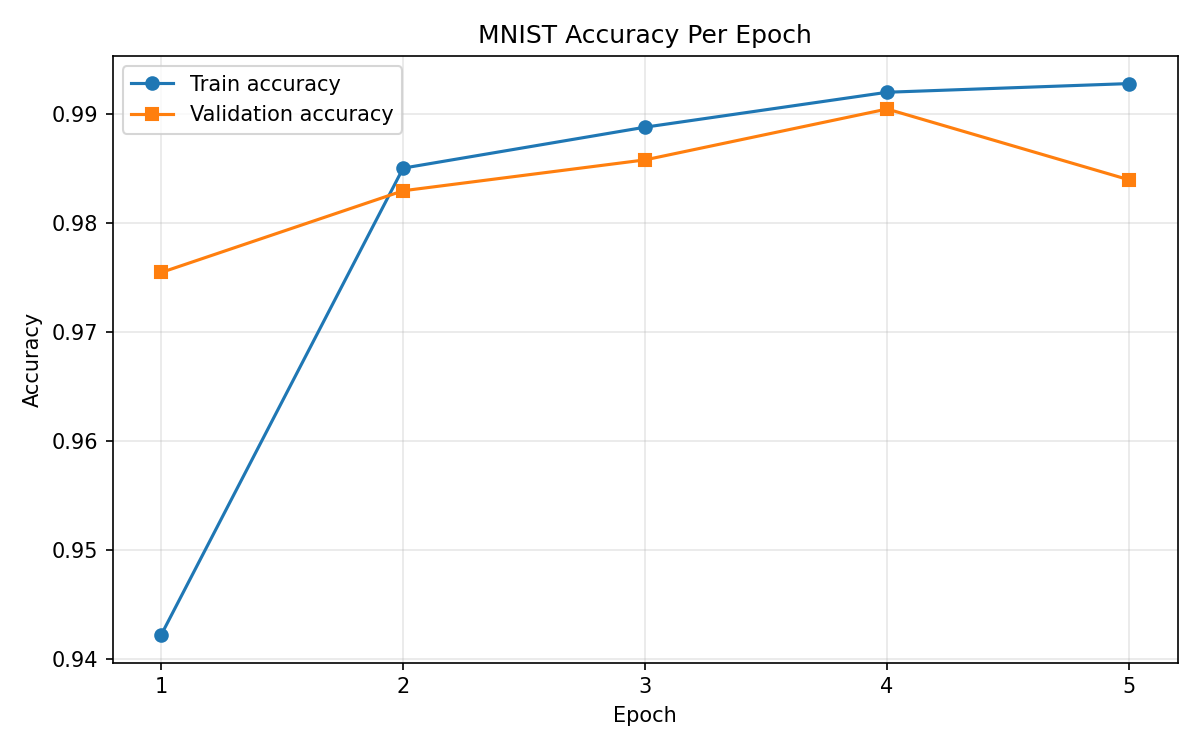

confusion_matrix.png


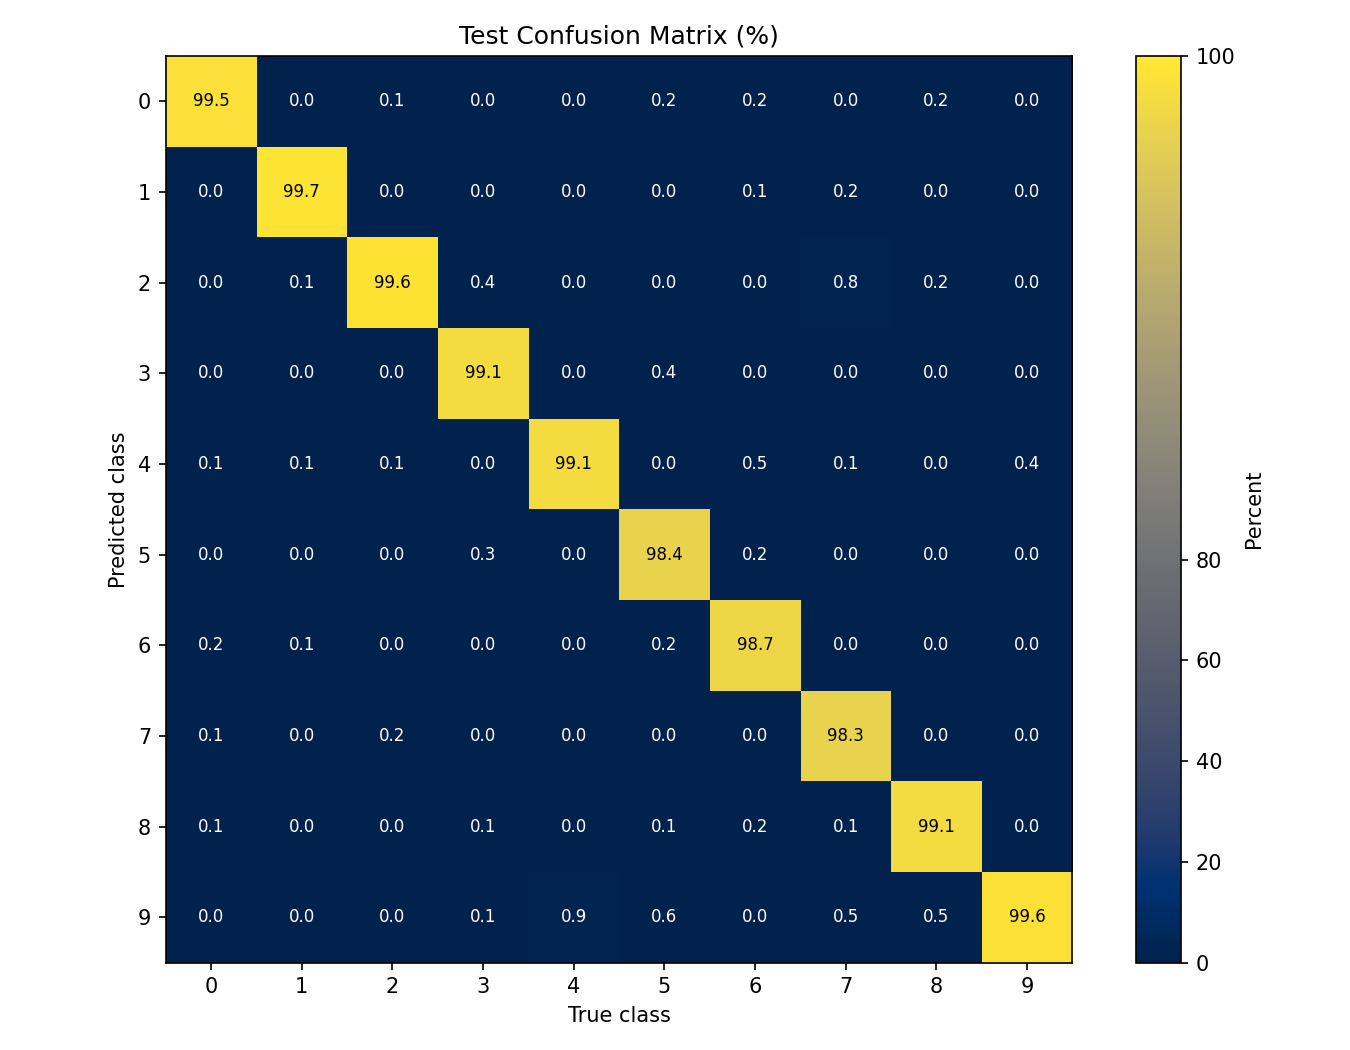


## cnn_deep_wide
loss_curve.png


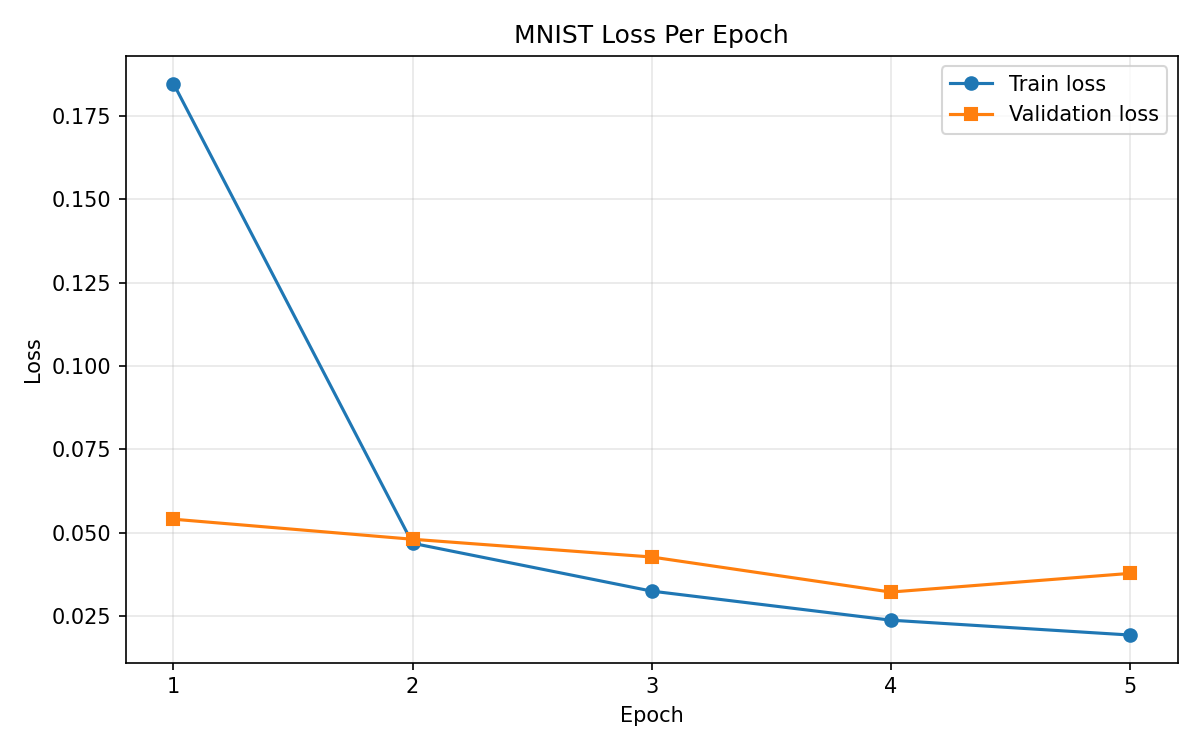

accuracy_curve.png


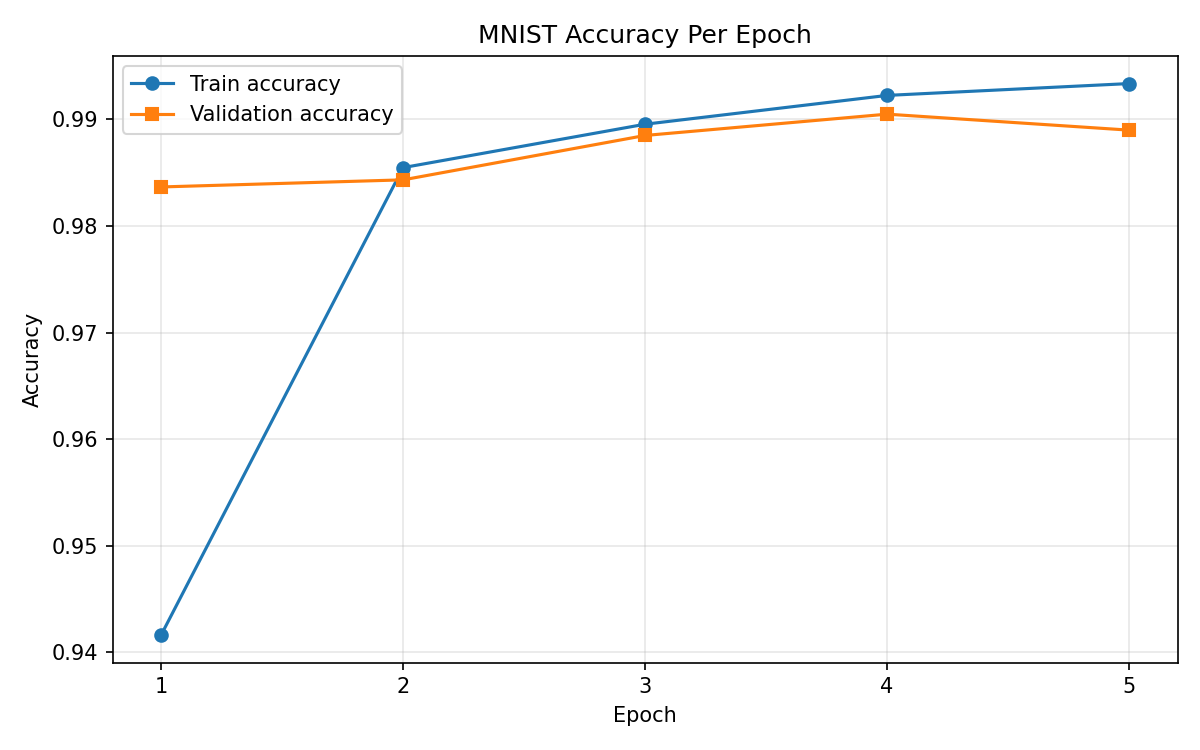

confusion_matrix.png


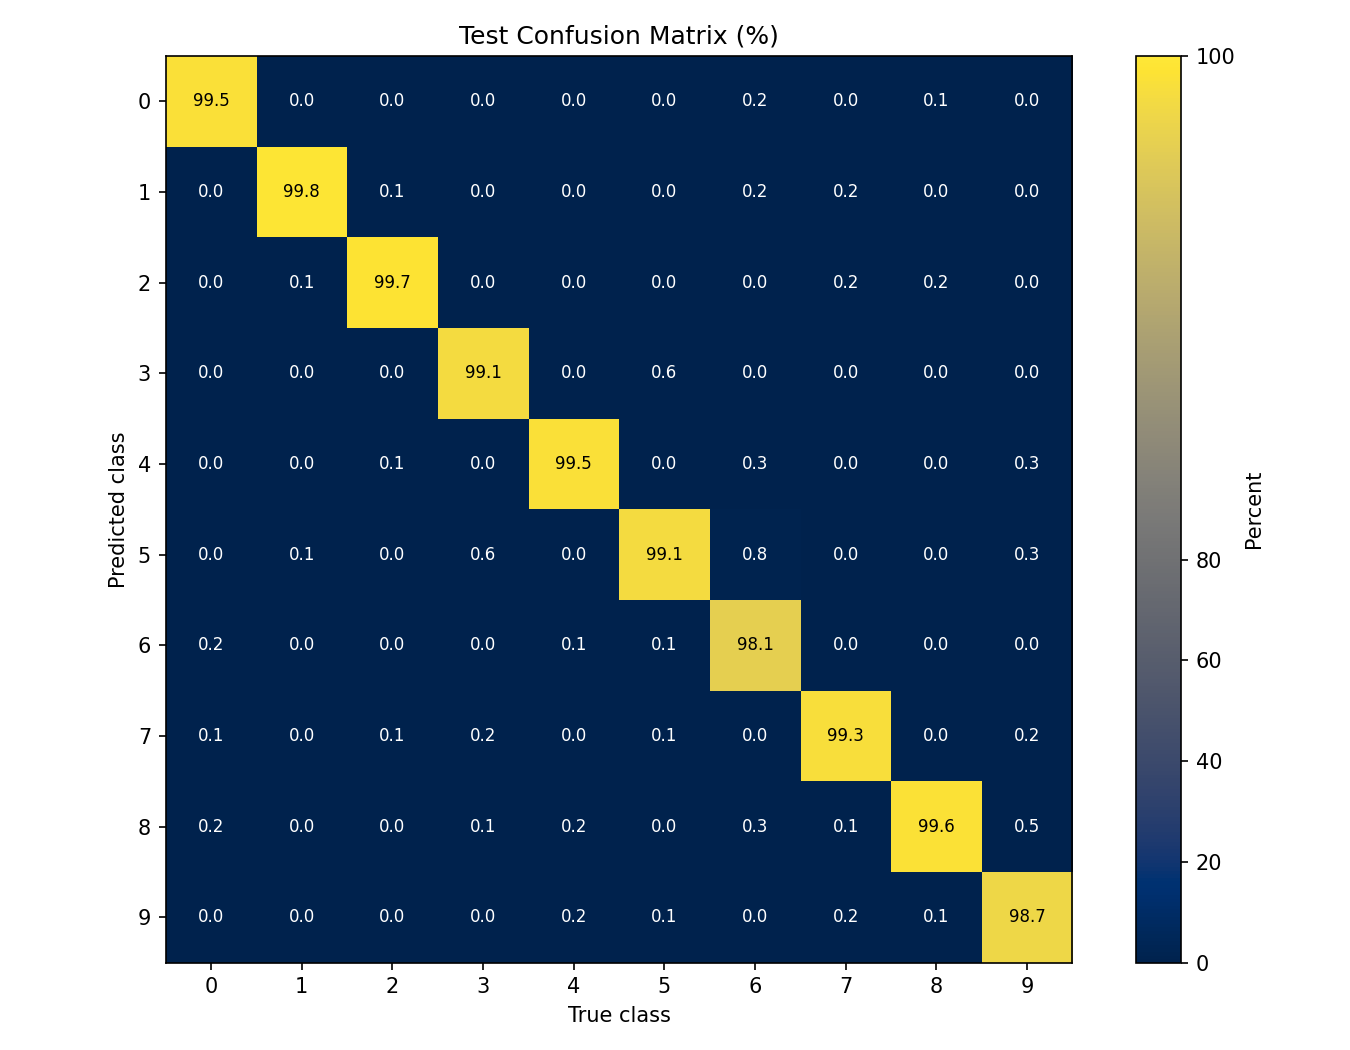

In [4]:
plot_files = [
    'loss_curve.png',
    'accuracy_curve.png',
    'confusion_matrix.png',
]

for run_name in RUN_NAMES:
    run_dir = Path(RUN_DIRS[run_name])
    print(f'\n## {run_name}')
    for plot_name in plot_files:
        print(plot_name)
        display(Image(filename=str(run_dir / plot_name)))


## First Vs Later Convolution Filters

The first convolution layer usually learns simple local patterns such as edges, stroke directions, and small blobs. Later convolution layers usually combine those earlier responses into more structured digit parts, for example curves, corners, loops, and stroke combinations that are useful for whole-digit recognition.


## cnn_small
conv_filters_first.png


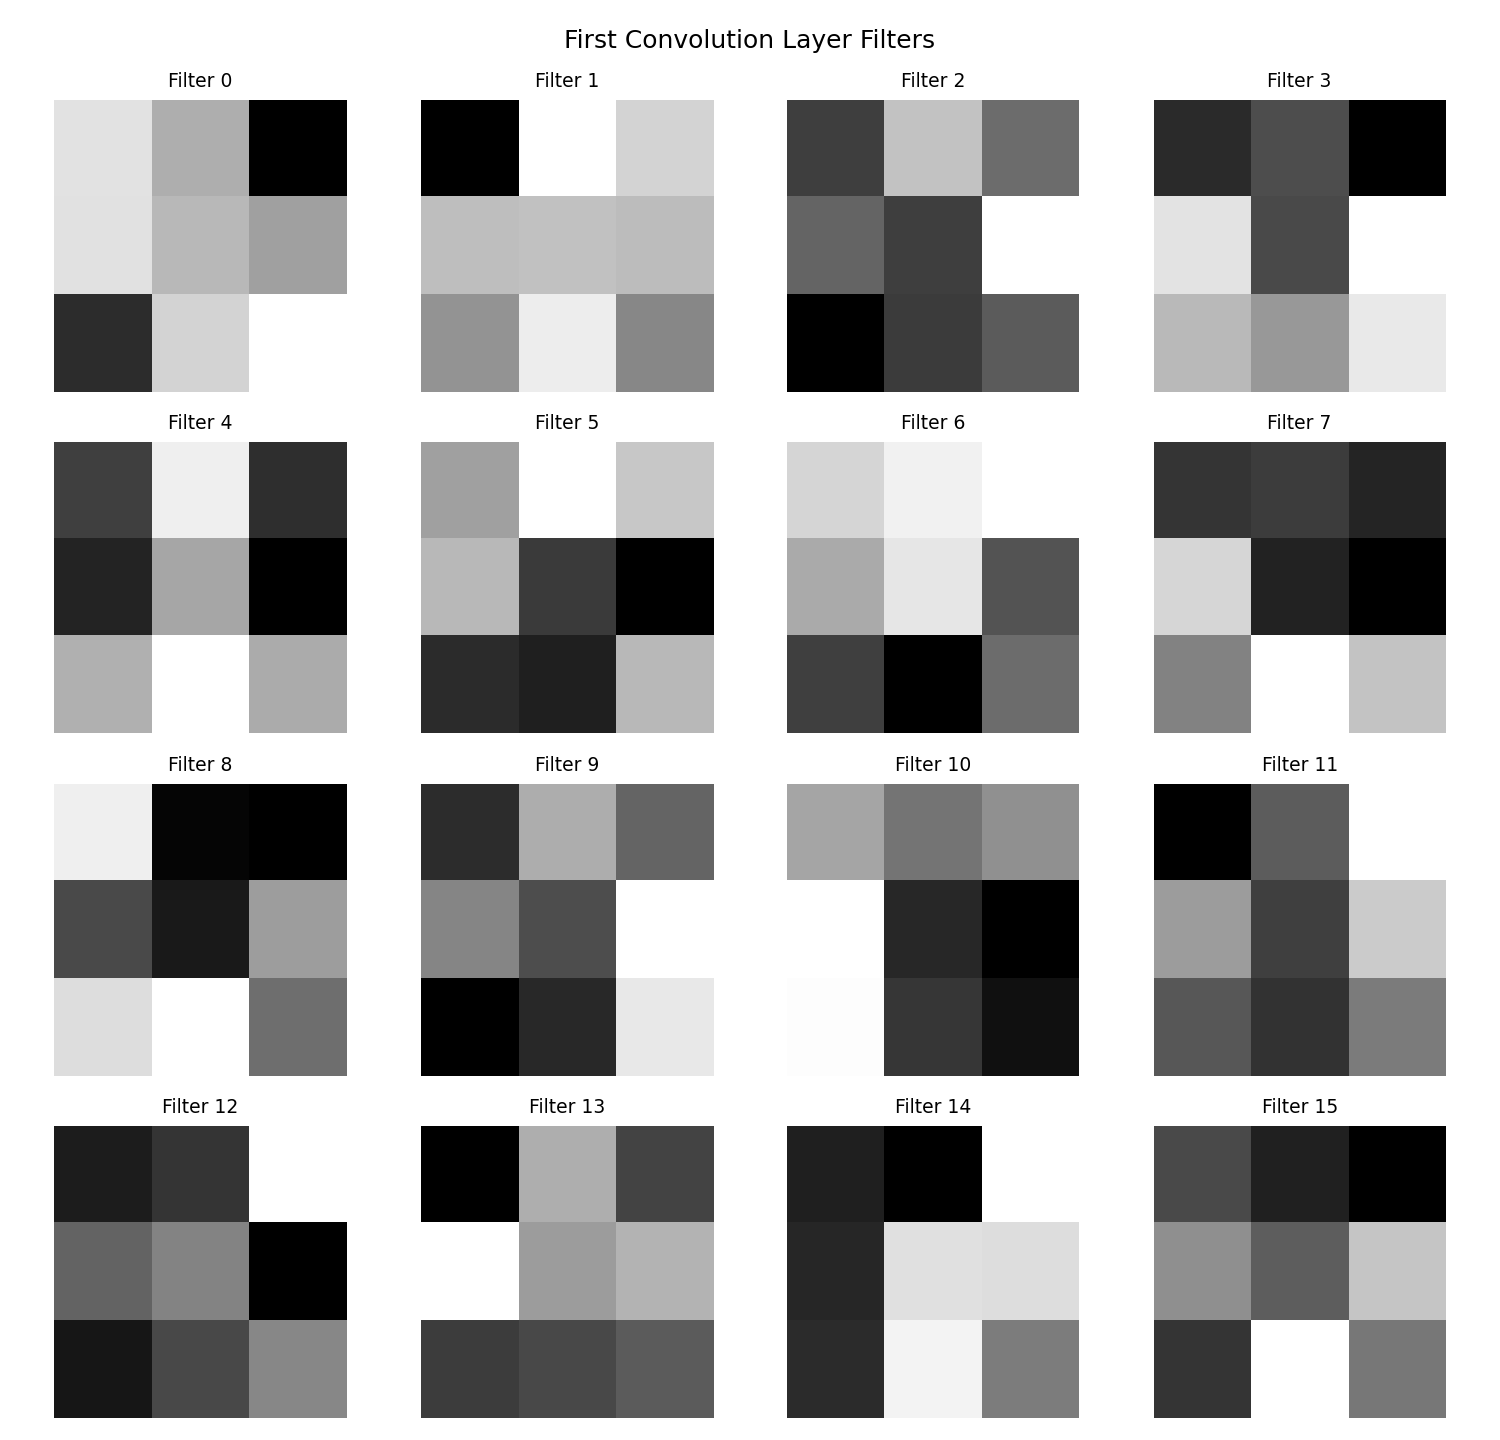

conv_filters_last.png


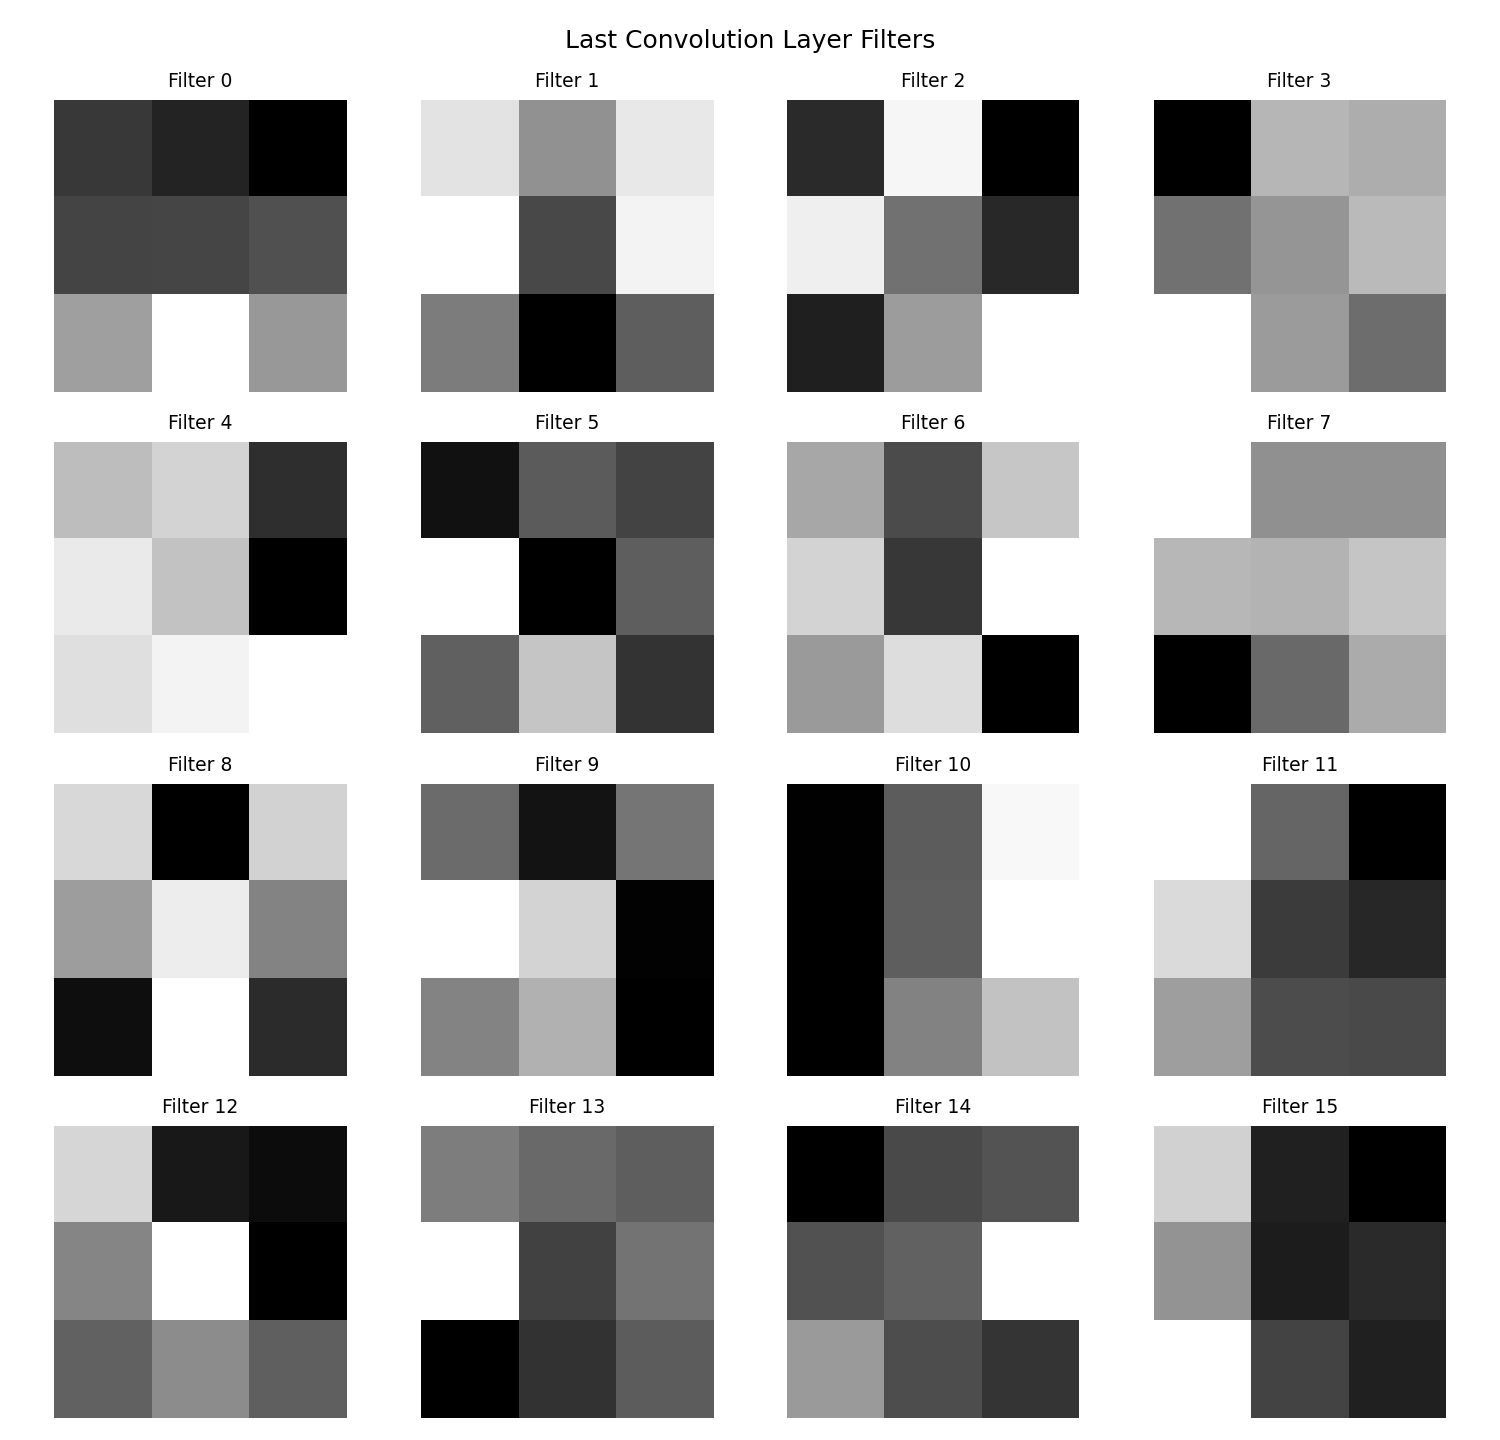


## cnn_medium
conv_filters_first.png


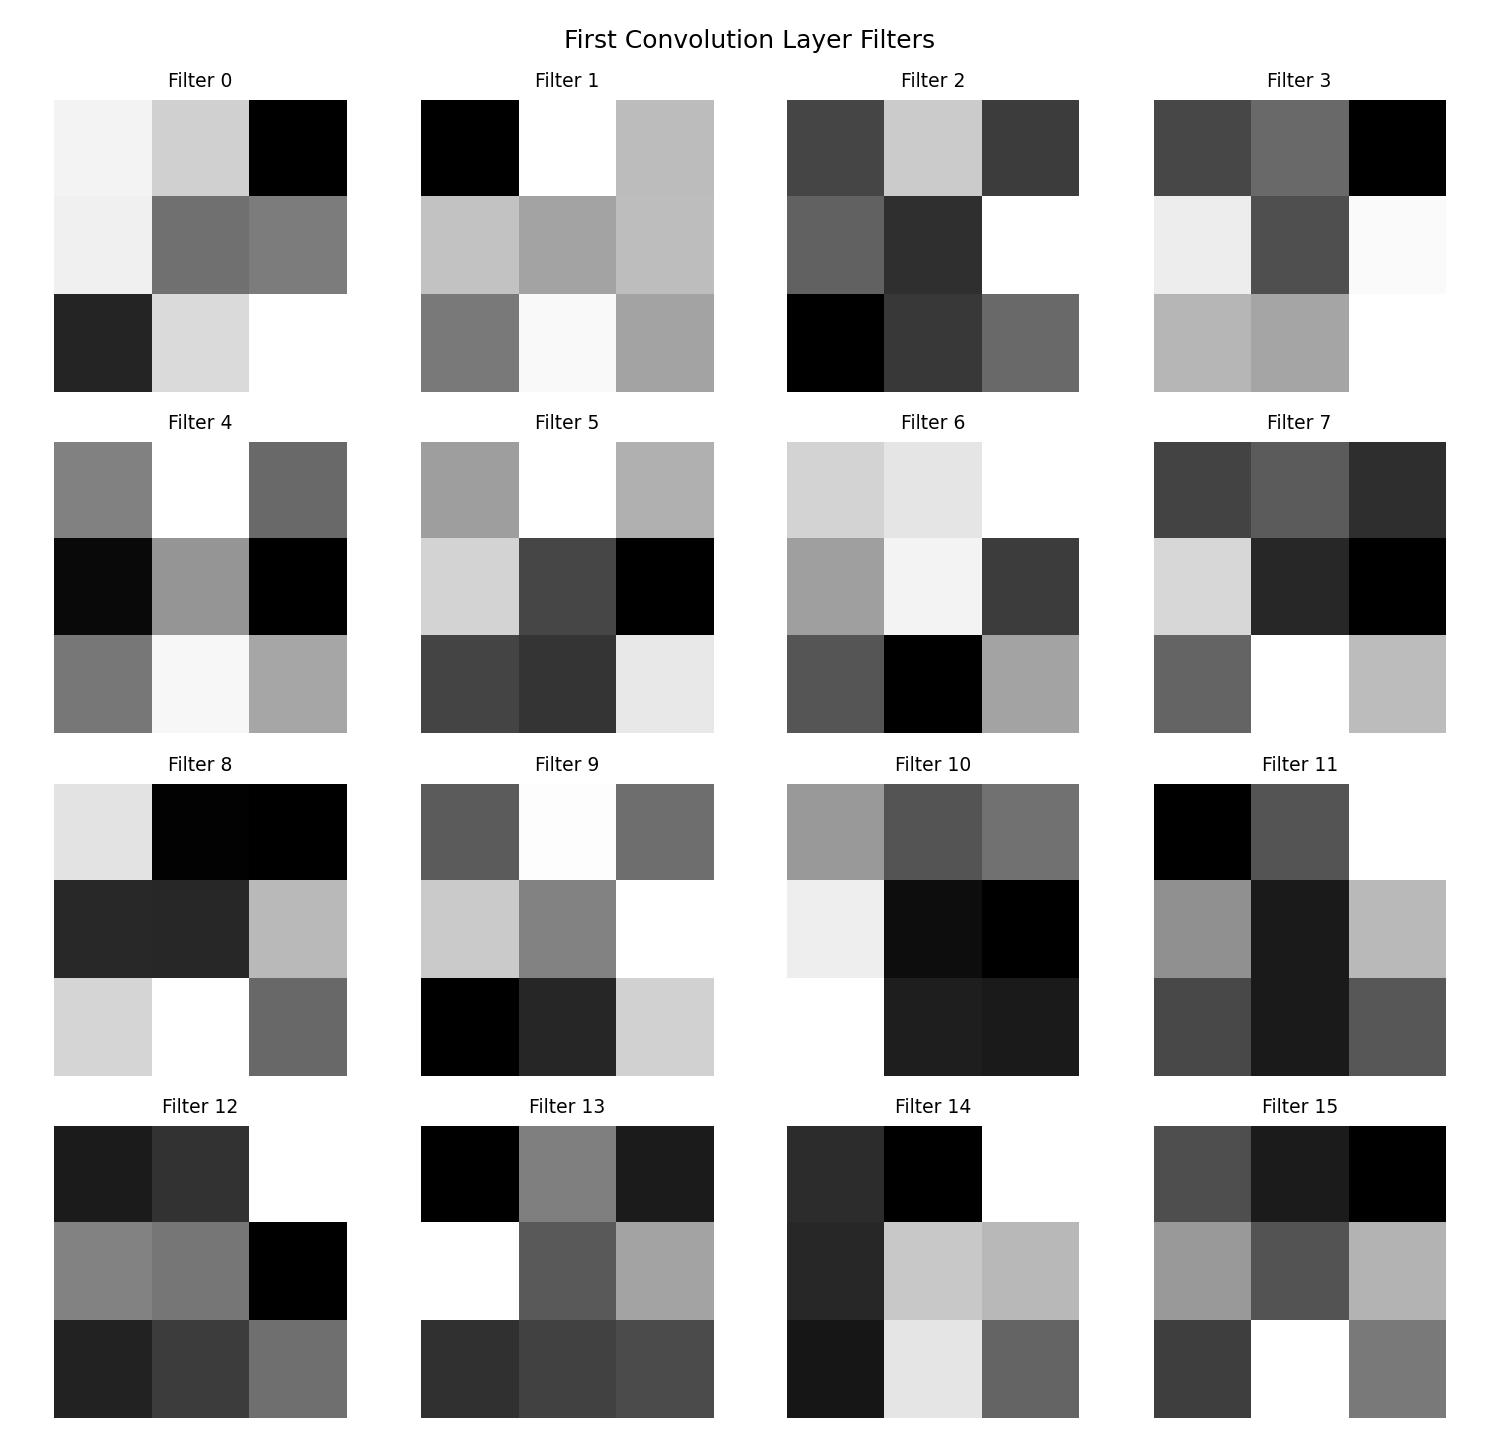

conv_filters_last.png


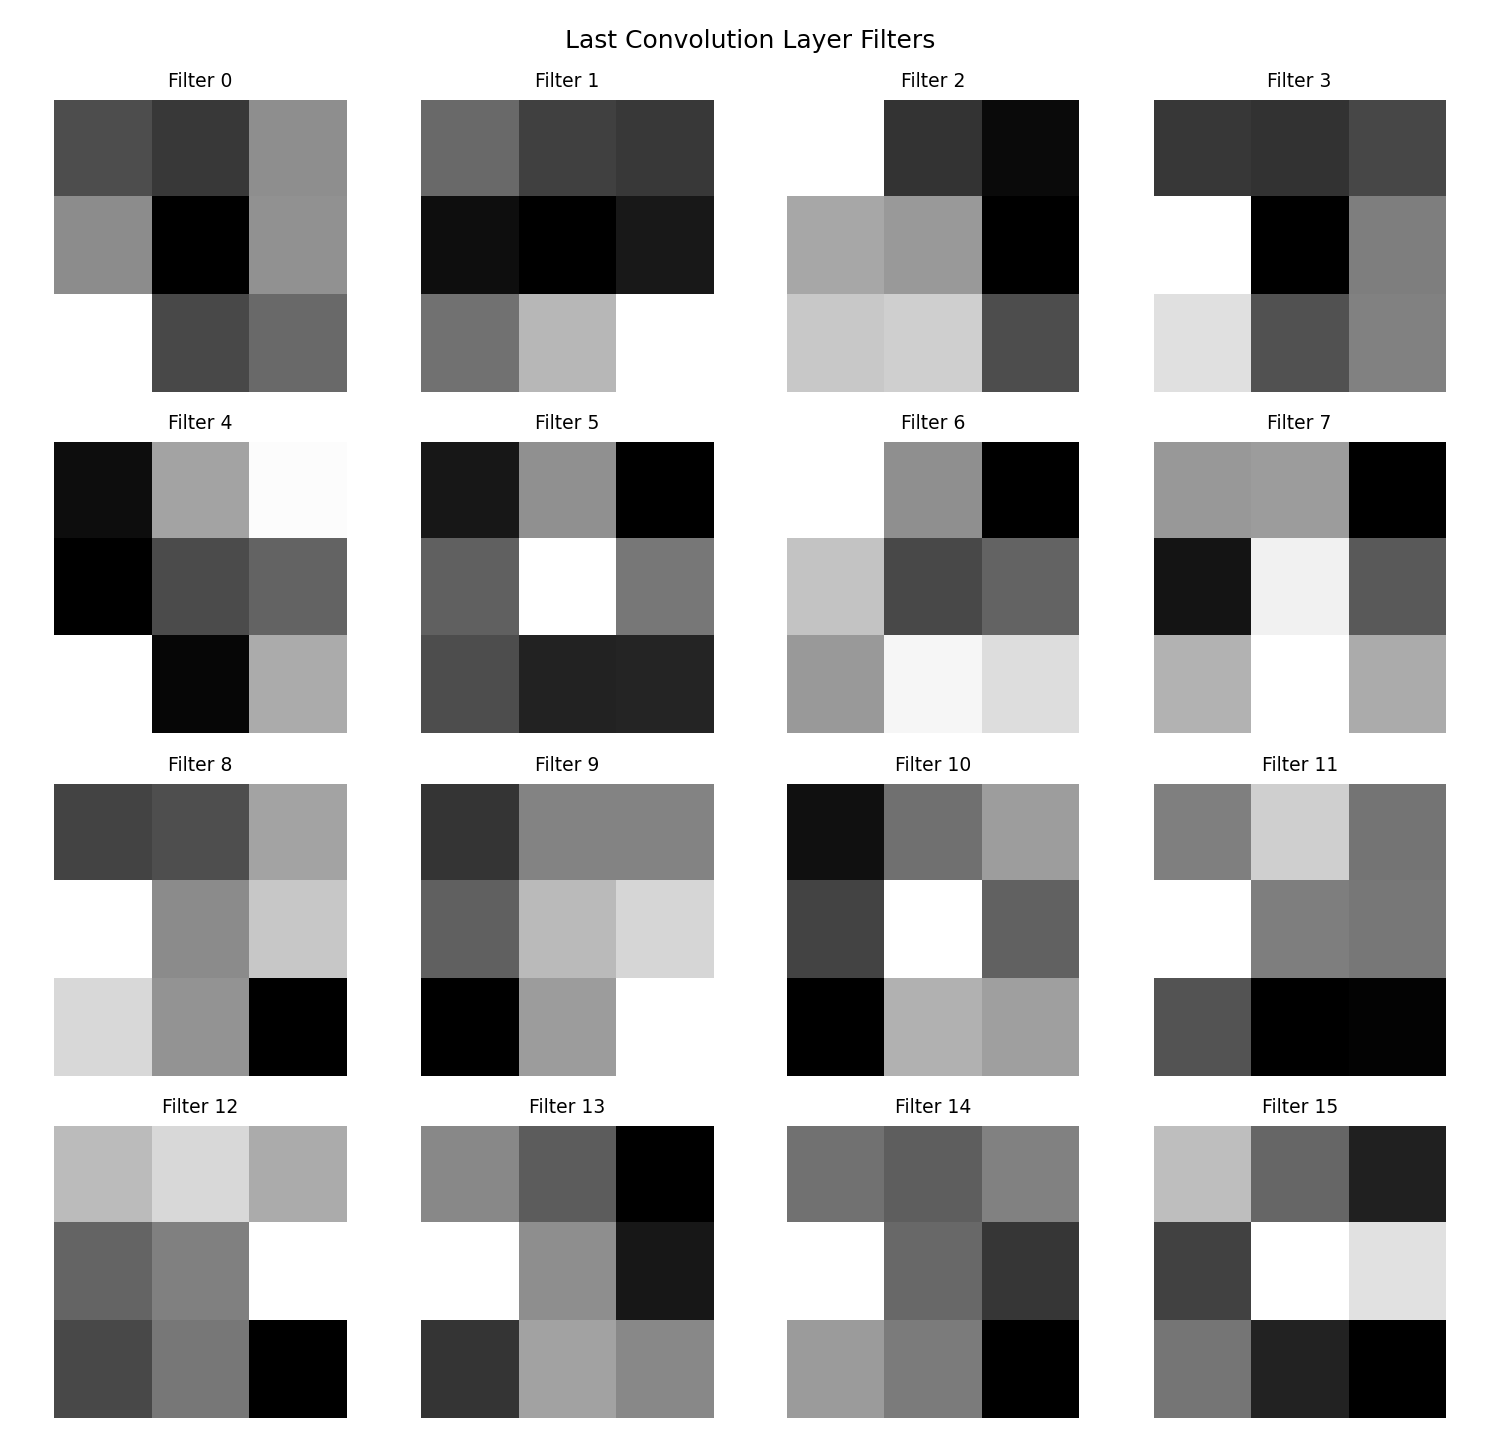


## cnn_dropout
conv_filters_first.png


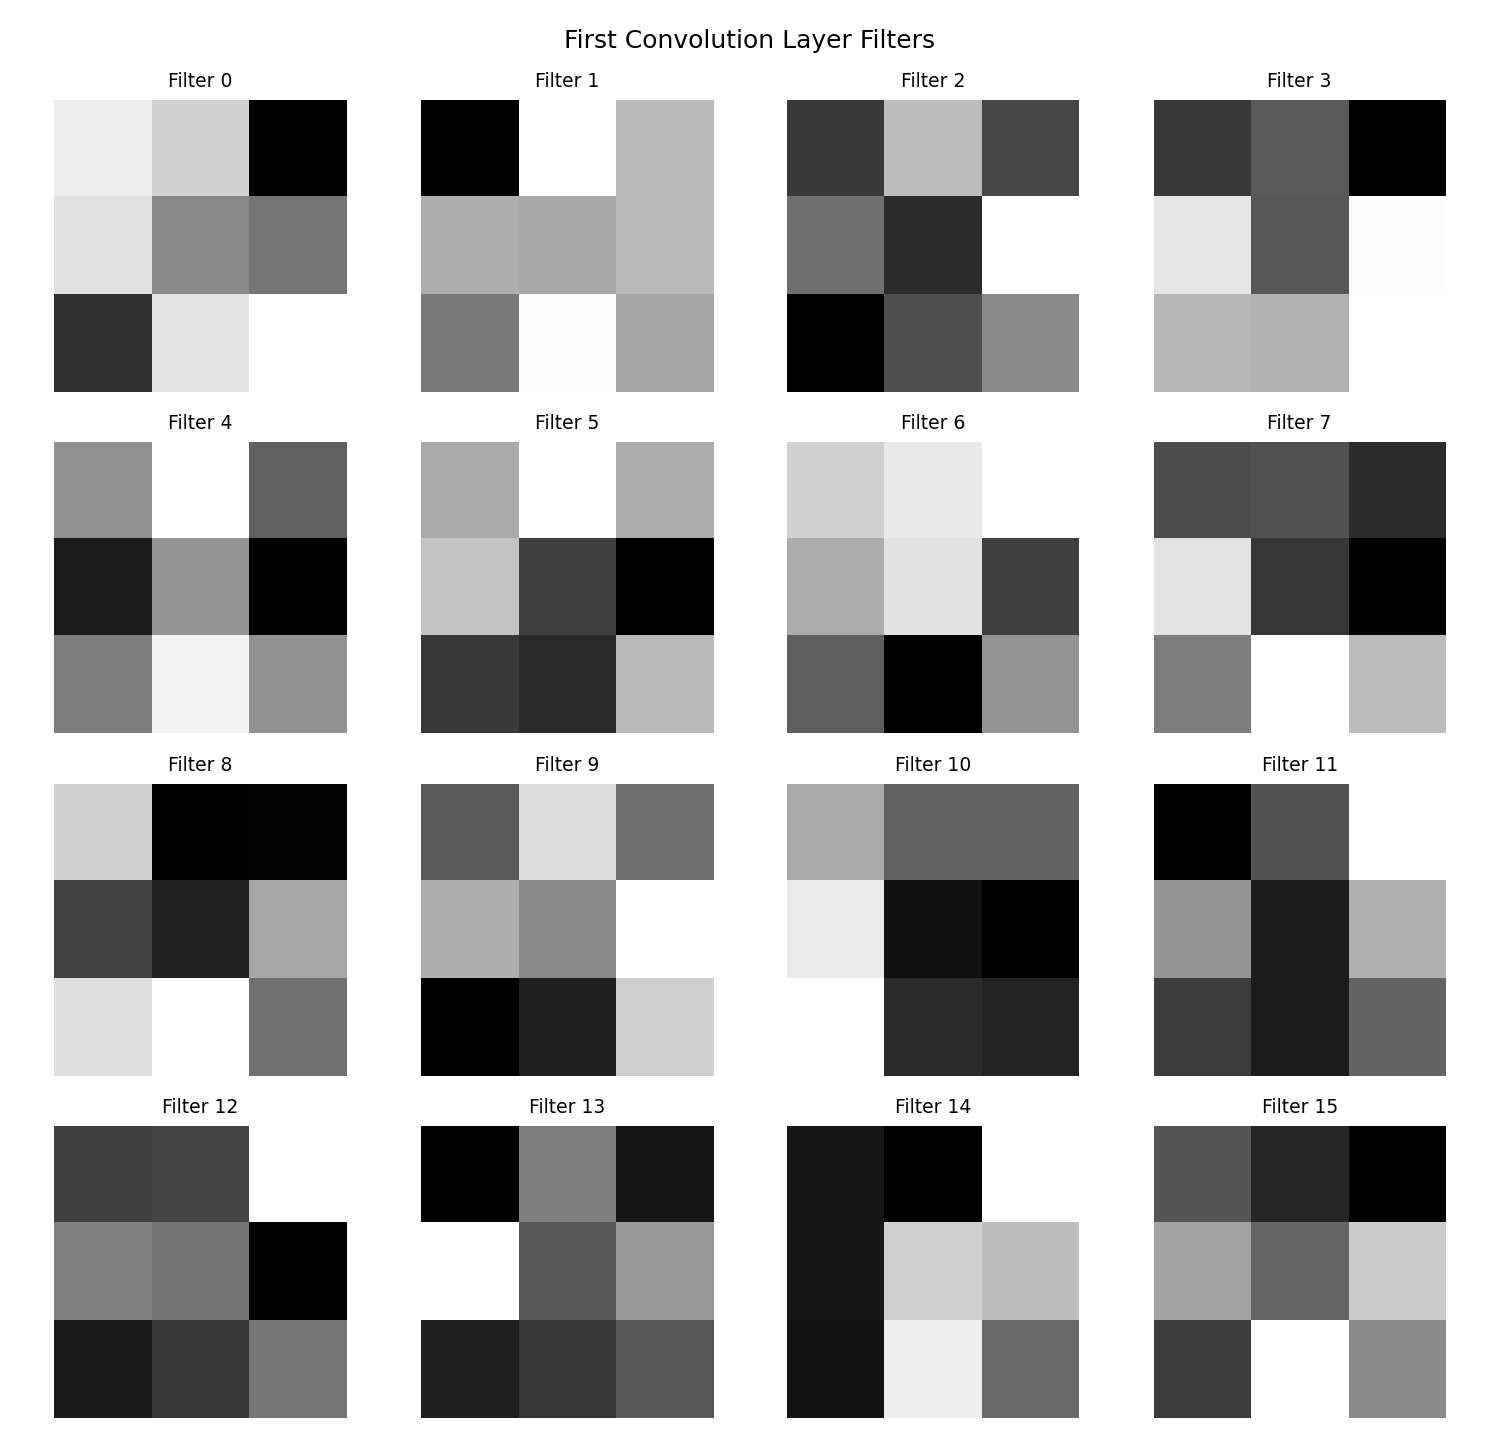

conv_filters_last.png


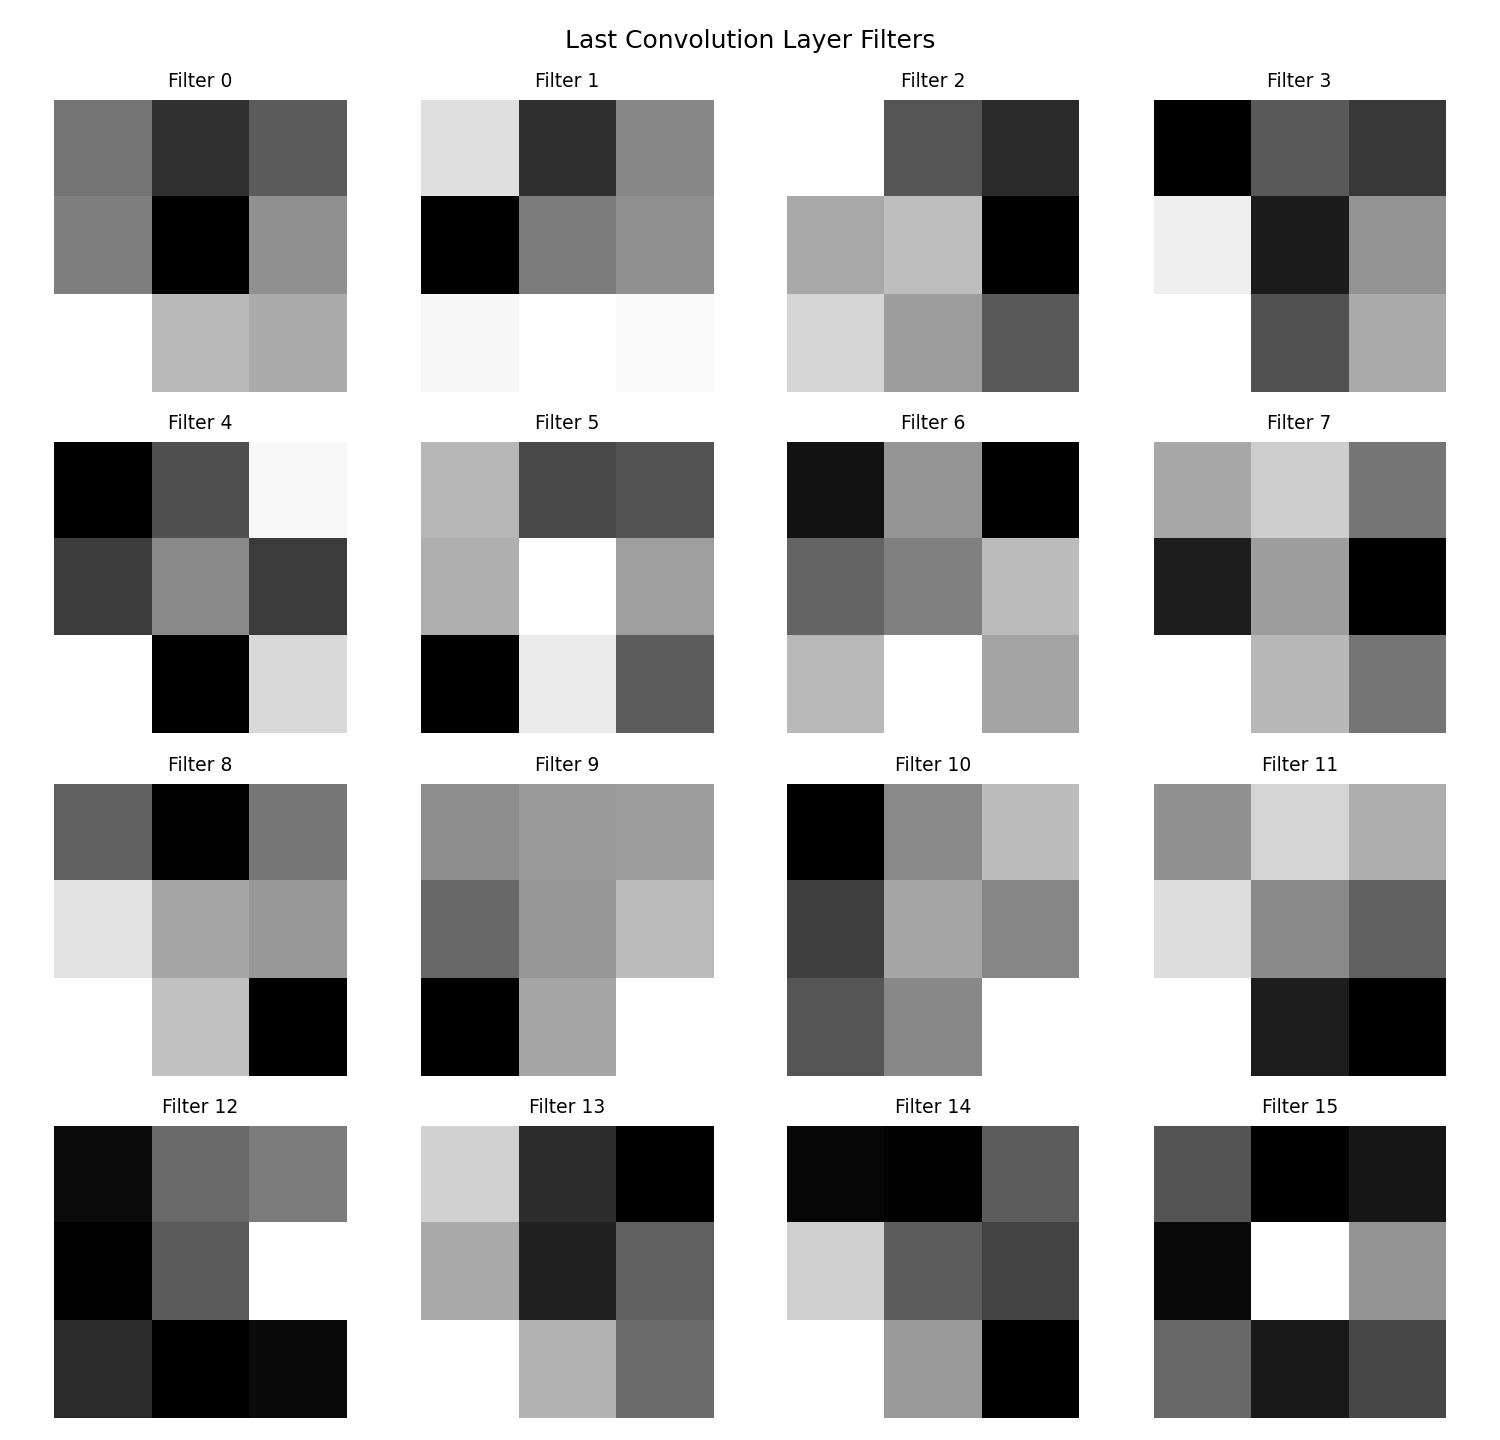


## cnn_deep_balanced
conv_filters_first.png


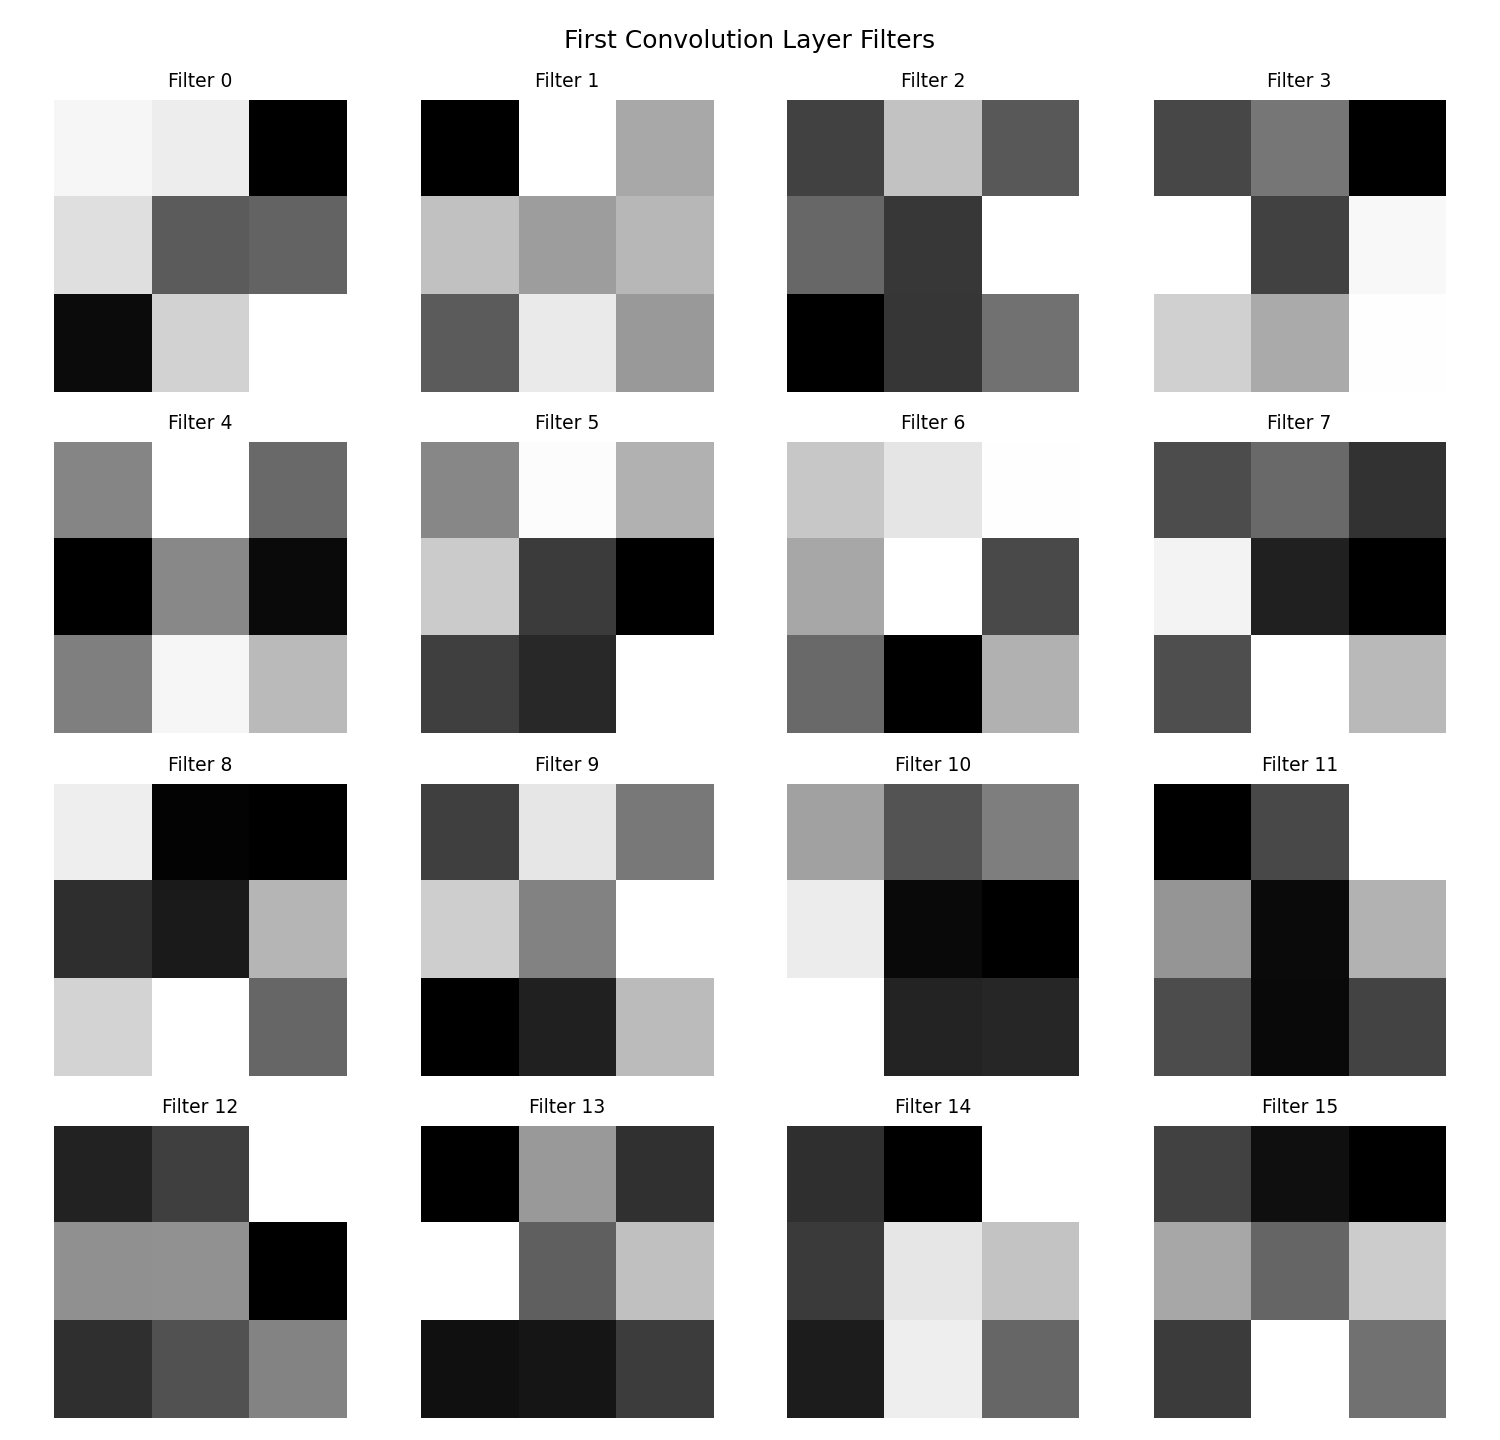

conv_filters_last.png


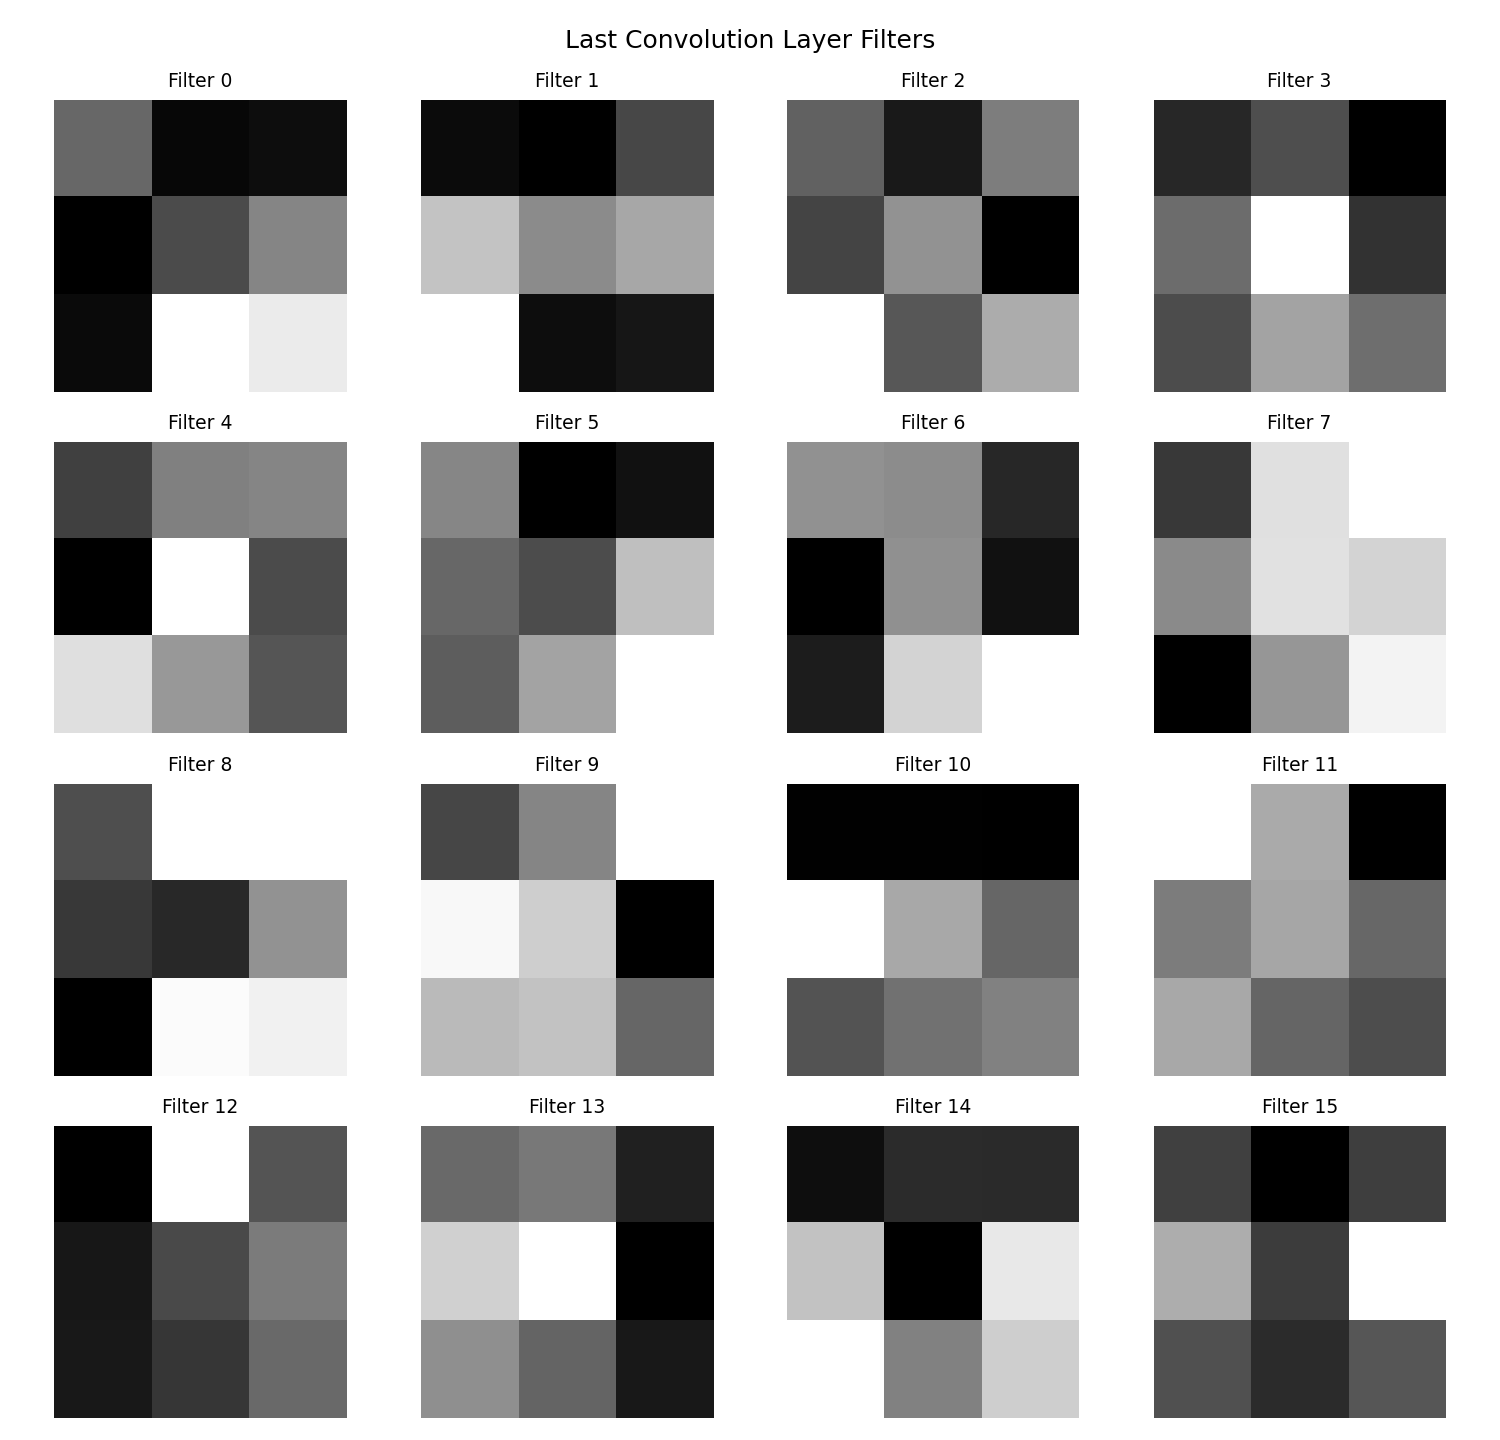


## cnn_deep_wide
conv_filters_first.png


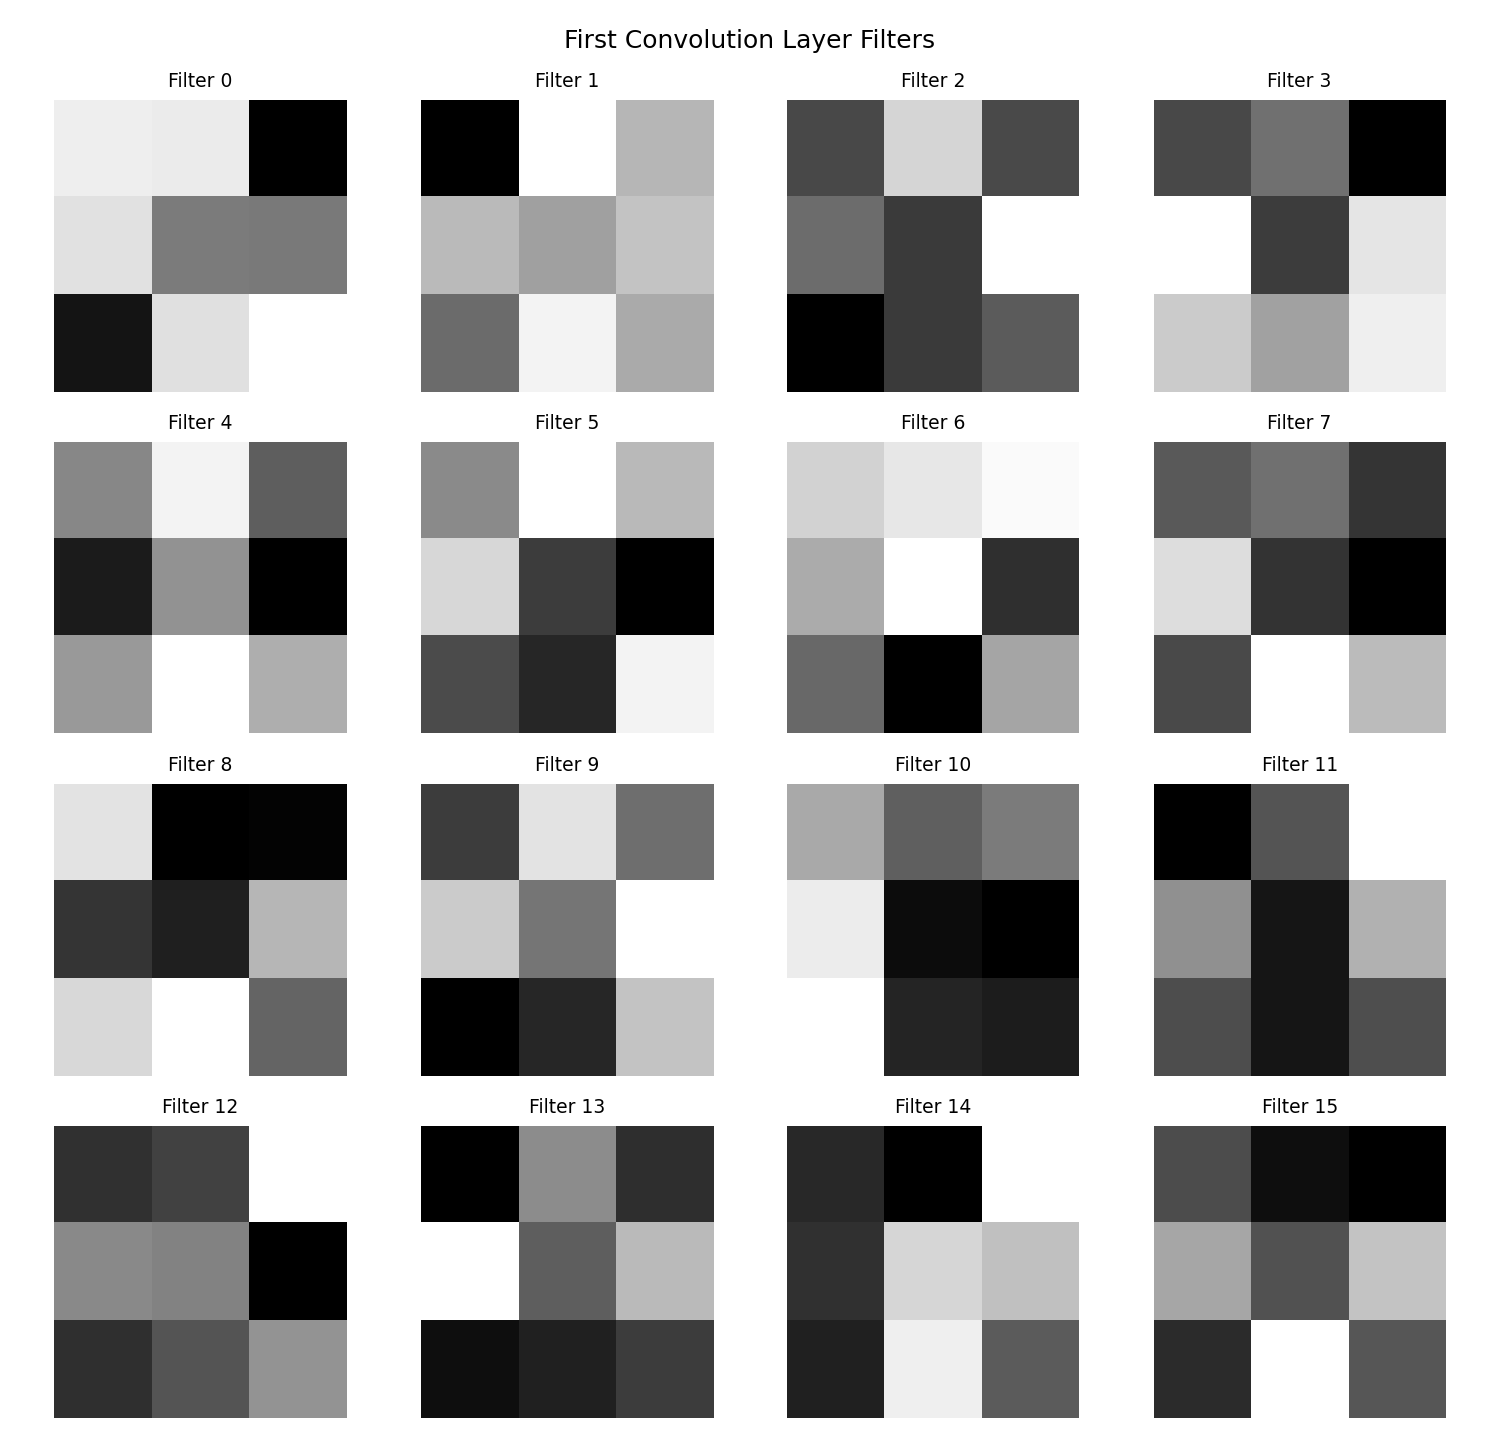

conv_filters_last.png


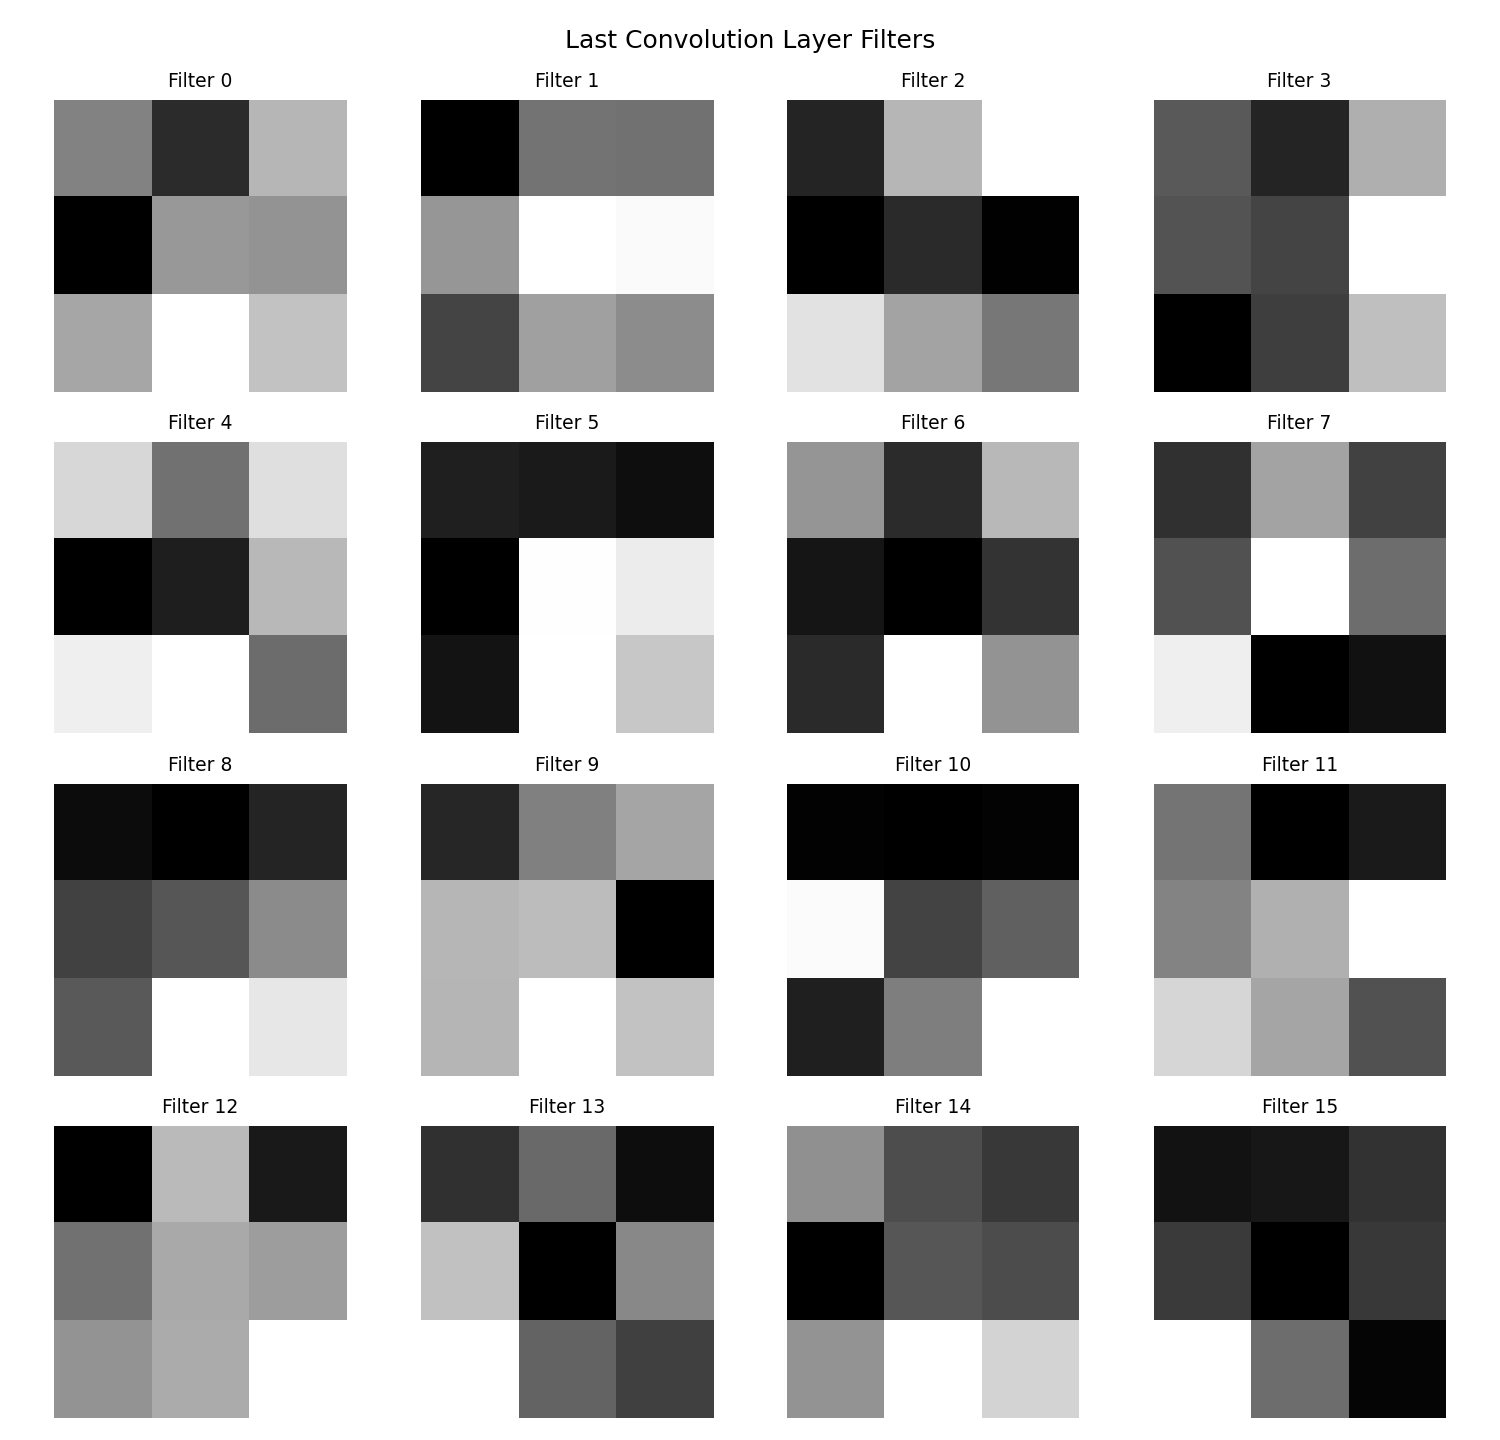

In [5]:
filter_plot_files = [
    'conv_filters_first.png',
    'conv_filters_last.png',
]

for run_name in RUN_NAMES:
    run_dir = Path(RUN_DIRS[run_name])
    print(f'\n## {run_name}')
    for plot_name in filter_plot_files:
        plot_path = run_dir / plot_name
        print(plot_name)
        if plot_path.exists():
            display(Image(filename=str(plot_path)))
        else:
            print('Missing:', plot_path)


## Architecture Notes

In [6]:
for row in rows:
    print(
        f"{row['model']}: {row['num_conv_layers']} conv layers | "
        f"channels={row['conv_channels']} | "
        f"params={row['trainable_parameters']:,} | "
        f"activation={row['activation']} | dropout={row['dropout']}"
    )

print('\nInterpretation:')
print('- More convolution layers increase representational depth.')
print('- First-layer filters tend to be edge or stroke detectors.')
print('- Later-layer filters represent combinations of earlier patterns.')
print('- Compare accuracy together with parameter count and training time.')


cnn_small: 2 conv layers | channels=[16, 32] | params=105,866 | activation=ReLU | dropout=0.0
cnn_medium: 2 conv layers | channels=[32, 64] | params=421,642 | activation=LeakyReLU | dropout=0.0
cnn_dropout: 2 conv layers | channels=[32, 64] | params=421,642 | activation=ReLU | dropout=0.3
cnn_deep_balanced: 3 conv layers | channels=[32, 64, 64] | params=356,298 | activation=ReLU | dropout=0.0
cnn_deep_wide: 3 conv layers | channels=[32, 64, 128] | params=390,410 | activation=ReLU | dropout=0.0

Interpretation:
- More convolution layers increase representational depth.
- First-layer filters tend to be edge or stroke detectors.
- Later-layer filters represent combinations of earlier patterns.
- Compare accuracy together with parameter count and training time.


## Final Remark

In [7]:
best_by_test = None
best_test_acc = -1.0
fastest_model = None
fastest_time = None

for run_name in RUN_NAMES:
    run_dir = Path(RUN_DIRS[run_name])
    summary = load_json(run_dir / 'summary.json')
    test_acc = summary['final_test_accuracy']
    total_time = summary['total_training_time_seconds']
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_by_test = run_name
    if fastest_time is None or total_time < fastest_time:
        fastest_time = total_time
        fastest_model = run_name

print(f'Best test accuracy: {best_by_test} ({best_test_acc:.2%})')
print(f'Fastest training run: {fastest_model} ({fastest_time:.2f}s)')


Best test accuracy: cnn_deep_wide (99.26%)
Fastest training run: cnn_medium (36.36s)


## Recommended Model

In [8]:
rows = []
for run_name in RUN_NAMES:
    run_dir = Path(RUN_DIRS[run_name])
    summary = load_json(run_dir / 'summary.json')
    rows.append({
        'model': run_name,
        'test_acc': summary['final_test_accuracy'],
        'time_s': summary['total_training_time_seconds'],
        'params': load_json(run_dir / 'config.json').get('trainable_parameters', 0),
    })

best_test_acc = max(row['test_acc'] for row in rows)
fastest_time = min(row['time_s'] for row in rows)

for row in rows:
    row['acc_gap'] = best_test_acc - row['test_acc']
    row['time_ratio'] = row['time_s'] / fastest_time if fastest_time > 0 else 1.0
    row['param_ratio'] = row['params'] / min(candidate['params'] for candidate in rows if candidate['params'] > 0)

preferred_order = {
    'cnn_medium': 0,
    'cnn_deep_balanced': 1,
    'cnn_deep_wide': 2,
    'cnn_small': 3,
    'cnn_dropout': 4,
    'mlp': 5,
}
recommended = min(
    rows,
    key=lambda row: (
        row['acc_gap'] > 0.002,
        row['acc_gap'],
        row['time_ratio'] > 1.25,
        row['param_ratio'] > 1.8,
        row['time_s'],
        preferred_order.get(row['model'], 99),
    ),
)

recommendation = (
    f"Among the tested CNN variants, {recommended['model']} gave the best balance "
    f"between simplicity, training time, and accuracy, so it was selected "
    f"as the final architecture."
)
print(recommendation)
recommendation


Among the tested CNN variants, cnn_deep_wide gave the best balance between simplicity, training time, and accuracy, so it was selected as the final architecture.


'Among the tested CNN variants, cnn_deep_wide gave the best balance between simplicity, training time, and accuracy, so it was selected as the final architecture.'